# 04 - Friction

## Purpose

This notebook continues a series working toward an accurate, mathematically
proven servo control loop, built on empirical data. Notebook 00
characterized the measurement chain, notebook 01 the four bridge states and
the coast spin-down, notebook 03 the back-EMF constant and the winding
resistance. This notebook measures the friction of the mechanism, from the
voltage that first moves it to the way it comes to rest.

The friction model is Coulomb plus viscous,

$$\tau_f = \tau_c\,\mathrm{sign}(\omega) + b_v\,\omega,$$

with $\tau_c$ the Coulomb torque and $b_v$ the viscous coefficient. Two
independent routes measure it in different units. In coast (route A) the
deceleration is $a + b\,v$ with $a = \tau_c / J$ and $b = b_v / J$. Under
drive at steady speed (route B) the motor current balances the friction,
$K_t\,i = \tau_c + b_v\,\omega$, so the steady-state current against speed
is a line $i = i_c + i_v\,\omega$ with $i_c = \tau_c / K_t$ and
$i_v = b_v / K_t$. Neither $J$ nor $K_t$ is known here, and the ratio
$\tau_c / b_v$ cancels both. It equals $a / b$ from route A and
$i_c / i_v$ from route B, and both are a speed, the speed at which viscous
friction equals Coulomb friction. Agreement of the two ratios is the test
this notebook is built around.

This notebook has three jobs:

1. Measure the breakaway duty and voltage per direction (section 5).
2. Measure the friction constants by both routes and test the ratio
   (sections 6 and 7).
3. Examine the approach to rest and the dependence of friction on position
   (section 8).

**The dataset is 2S.** Every coefficient below comes from the 2-cell
battery dataset `sg90-a__dev-v006-D__2s`. The USB dataset appears once, in
section 5.4, as a check that the breakaway trend points the same way, and
it is never a source: the USB rail droops 3.5% across the duty range and
dips 22% on spin-up, so a breakaway duty measured on it is partly a
measurement of the supply.

Two earlier runs are retired: a 2-cell battery run on the previous
measurement chain, and a laptop-USB run on this chain. Neither is a fit
input anywhere below. Where an old number is quoted for comparison, I say
which of the two it came from and which of the three things that changed
(chain, supply, drive-window length) could have moved it.

## 1. Test setup

The device under test is an SG90-class hobby servo with its stock
electronics replaced by a custom controller board. The signal chain is the
one described in notebooks 00 and 01, and the parts are declared in
`oscnb/boards.py` rather than written down here. The points this notebook
depends on:

- A brushed DC motor driven by an H-bridge with 20 kHz center-aligned PWM
  under slow decay, so the OFF portion of every period is brake. **Duty**
  is the fraction of each period in the drive state.
- A gear train couples the motor to the output shaft, and a potentiometer
  on the output shaft is read by the MCU's 12-bit ADC. Position stays in
  wiper volts and speed in wiper volts per second. The pot-derived speed
  carries a ripple with a period of a fraction of a wiper volt (notebook
  01, section 6.1), so every speed estimate below states the window it
  averages over.
- A shunt in the motor return path, amplified at fixed gain, gives the
  motor current. The crest scan samples it at the center of the drive
  window. The amplifier output includes an offset, measured from the
  baseline segment of each recording and subtracted throughout.
- Both motor terminals are read through dividers whose bottom legs return
  to a common bias node $V_B$, each tap with a reservoir capacitor, so both
  terminals stay readable during coast and their difference reads the
  back-EMF free of the bias. That difference is the direct speed signal
  route A uses.

Three things differ from the retired USB run and each of them moves numbers
below.

- **The supply is a 2-cell battery.** The rail at the driven terminal is
  7.76 V and holds, where USB delivered 4.55 V and sagged under load. Every
  speed, voltage and current here is larger for the supply alone.
- **The ADC is clocked at 24 MHz**, which removes the code-skipping defect
  the 48 MHz build had (notebook 03, section 4.3). Nothing here interpolates
  any channel.
- **The grid's drive windows are sized by travel**, from 1500 ms at 5% duty
  down to 124 ms at 100%, where the retired runs used a flat 80 ms. Section
  6.1 shows what that does to route B: the steps now settle inside their
  own window, and the extrapolation that the 80 ms grid needed becomes a
  correction of a few percent instead of tens of percent.

**The board is a hacked rig.** The board under this session is a
development board that has been reworked by hand several times (the shunt,
the dividers, the bias return, the reservoir capacitors, a repaired
amplifier pad). I know of one defect on it that the next board revision
does not have. The bus telemetry stream couples into the current
amplifier's output, so a shunt sample taken while a frame is going out on
the wire can read a few counts off. On the scan geometry of this firmware
build it does not show at rest (notebook 00, section 5.2, bins the rest
current by position inside the frame and finds it flat within a count), but
one count is about 0.9 mA on this chain, so a few counts is a few
milliamps, and route B's whole line lives between 58 and 134 mA. A few
milliamps there is a few percent of $i_c$. It is a known limitation of this
board, and I do not code around it anywhere in this notebook.

## 2. Constants and unit conversions

Nothing about the hardware is written down in this notebook. The
measurement chain (shunt, divider legs, amplifier gain, VDD, bias network,
sample rate, drive-window floors) lives in `oscnb/boards.py`, and the
mechanism (gear ratio, pot mapping, travel, and the measured values other
notebooks have contributed) in `oscnb/servos.py`. A dataset's
`manifest.json` names which board and which servo produced it, and reading
a recording checks its own `sense` block against that board, so a dataset
pointed at the wrong hardware fails at load.

A drive-window current sample is settled for duty at or above the board's
current floor and a voltage sample at or above its voltage floor, and the
streamed `window_valid` flag encodes the current floor. The breakaway
ladder of section 5 runs to 18% duty, so its top rungs sit above both
floors, but the onset itself lands below the current floor and its current
is shown rather than fitted.

With the divider's bottom leg returned to the bias $V_B$, a terminal
voltage $V_t$ reaches the ADC pin as

$$\text{tap} = \frac{V_t}{r} + \frac{r - 1}{r} V_B, \qquad V_t = r\,\text{tap} - (r - 1)\, V_B, \qquad r = \frac{R_\text{top} + R_\text{bot}}{R_\text{bot}}$$

so `board.term_v(tap, vb)` is the second form. On this chain the two taps
rest 4 counts apart, down from 18 on the previous one, and every absolute
terminal voltage below uses the rest reading of its own terminal in its own
recording, which absorbs the split as an offset and makes $v_A - v_B$ read
zero at rest.

**The winding resistance** enters once, in section 5.3, to turn the
breakaway voltage into a model-derived current. It is an input, taken from
the servo registry rather than typed here, and it is currently in dispute:
the registry carries 4.5 Ohm [4.3, 4.8] from notebook 03's USB run, while
notebook 03 re-run on this 2S dataset gives 4.22 [4.01, 4.43]. Section 5.3
carries the union of the two brackets rather than picking one, and section
9 says what would settle it.

Two caveats carry over. The ADC reference is the design value, so every
voltage scales with the true VDD of this unit. The divider, shunt and gain
are design values with unmeasured tolerances.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.optimize import least_squares, curve_fit

import oscnb

# 2S IS PRIMARY. Every coefficient in this notebook comes from this dataset. USB appears
# only in section 5.4 as a trend check: its rail droops 3.5% across duty and dips 22% on
# spin-up, so a breakaway duty measured on it is partly a measurement of the supply.
ds = oscnb.use("sg90-a__dev-v006-D__2s")
board, servo = oscnb.current().board, oscnb.current().servo

TICK_HZ = board.tick_hz     # 20 kHz, one telemetry sample per control tick
Q15 = 32767                 # duty full scale as encoded on the wire

# The one input from notebook 03, read from the registry rather than typed. Notebook 03
# re-run on 2S gives 4.22 [4.01, 4.43]; the registry still carries its USB figure. Section
# 5.3 carries the union of the two brackets.
R_W = servo.measured["r_winding_measured"]
R_WINDING_OHM = R_W.value
R_WINDING_LO, R_WINDING_HI = min(R_W.lo, 4.01), max(R_W.hi, 4.43)

def term_V(tap, vb):
    return board.term_v(tap, vb)

pd.DataFrame([
    {"quantity": "converter step", "value": board.v_adc_per_count * 1e3, "unit": "mV per count"},
    {"quantity": "terminal divider ratio r", "value": board.div_ratio, "unit": ""},
    {"quantity": "terminal difference", "value": board.v_term_per_count * 1e3, "unit": "mV per count"},
    {"quantity": "terminal bias VB, nominal", "value": board.vb_nom_v * 1e3, "unit": "mV"},
    {"quantity": "motor current", "value": board.a_per_count * 1e3, "unit": "mA per count"},
    {"quantity": "drive window settled, current", "value": board.floor_i_pct, "unit": "% duty and above"},
    {"quantity": "drive window settled, voltage", "value": board.floor_v_pct, "unit": "% duty and above"},
    {"quantity": f"winding resistance (input, {R_W.source})", "value": R_WINDING_OHM, "unit": "Ohm"},
    {"quantity": "winding resistance bracket carried", "value": R_WINDING_HI - R_WINDING_LO, "unit": "Ohm wide"},
]).set_index(["quantity", "unit"]).round(4)

dataset  sg90-a__dev-v006-D__2s
supply   2s
rig      SG90 clone, unit A on osc-dev-v006 board D (bodged toward rev-2A)



,captures,recordings per capture,names
experiment,,,
breakaway,5,1,sweep
bridge,5,3,"fast, slow, spindown"
grid,10,1,sweep
reversal,5,1,sweep
ripple,5,1,sweep
stepcoast,5,5,"step120, step20, step40, step60, step80"



derived constants (what the hardware is)


value
where            quantity                                           unit                         
board            converter step                                     mV per count           0.8057
                 terminal divider ratio r                                                  3.0606
                 terminal difference                                mV per count           2.4658
                 terminal bias VB                                   mV                   627.9352
                                                                    counts               779.4008
                 driven-low terminal reads                          counts               524.7451
                 motor current                                      mA per count           0.8952
                                                                    counts per A        1117.0909
                 shunt                                              mOhm                  60.0000
                 amplifier gain                                     x                     15.0000
                 rail tap ratio                                                            2.5000
                 sample rate                                        samples per ms        20.0000
                 current settled from (UNVERIFIED)                  % duty                13.3333
                 voltage settled from (UNVERIFIED)                  % duty                13.3333
servo            pot intercept                                      counts               232.0000
                 pot slope                                          counts per degree     19.9600
                 envelope low                                       counts (10 deg)      431.6000
                 envelope high                                      counts (170 deg)    3625.2000
                 runway                                             counts              3193.6000
                 seek guard low                                     counts               432.0000
                 seek guard high                                    counts              3625.0000
servo (measured) gear_ratio_measured [234.73, 234.73] mechanical... :1                   234.7300
                 ripple_order_measured [6, 6] bringup isns-diff ... per motor rev          6.0000
                 kv_measured [7880, 8040] bringup isns-diff run28   RPM/V               7960.0000
                 kt_measured [1.19, 1.21] bringup isns-diff run28   mN-m/A                 1.2000
                 r_motor_measured [4.16, 4.24] bringup isns-diff... Ohm                    4.2000
                 l_motor_measured [0.45, 0.55] bringup isns-diff... mH                     0.5000
                 stall_current_measured [1.45, 1.55] bringup isn... A                      1.5000
                 stall_torque_measured [1.75, 1.85] bringup isns... mN-m                   1.8000
                 free_run_current_measured [0.078, 0.084] bringu... A                      0.0810
                 r_winding_measured [4.3, 4.8] nb03, full duty o... Ohm                    4.5000
                 pot_scale_measured [19.3, 19.43] nb06 sec 5.5, ... counts/deg            19.3000
                 coast_bemf_slope_measured [0.19, 0.204] nb01, c... V per wiper V/s        0.1970
                 ke_measured [7.44, 7.73] nb03 route R: ripple s... mV per motor rev/s     7.5840


measured values (what someone found when they looked)


value                 unit           bracket  \
where quantity                                                            
board vb_bias            781.000               counts        [775, 783]   
      rail_droop_usb      -3.500  % over 20-100% duty          [-4, -3]   
      opa_noise_floor      2.200           counts RMS          [2, 2.4]   
      esd_clamp_skew       1.800               V bemf        [1.7, 1.9]   
servo gear_ratio         234.730                   :1  [234.73, 234.73]   
      ripple_order         6.000        per motor rev            [6, 6]   
      kv                7960.000                RPM/V      [7880, 8040]   
      kt                   1.200               mN-m/A      [1.19, 1.21]   
      r_motor              4.200                  Ohm      [4.16, 4.24]   
      l_motor              0.500                   mH      [0.45, 0.55]   
      stall_current        1.500                    A      [1.45, 1.55]   
      stall_torque         1.800                 mN-m      [1.75, 1.85]   
      free_run_current     0.081                    A    [0.078, 0.084]   
      r_winding            4.500                  Ohm        [4.3, 4.8]   
      pot_scale           19.300           counts/deg     [19.3, 19.43]   
      coast_bemf_slope     0.197      V per wiper V/s     [0.19, 0.204]   
      ke                   7.584   mV per motor rev/s      [7.44, 7.73]   

                                                                   source  \
where quantity                                                              
board vb_bias                     Hi-Z rest baseline, 2S grid + stepcoast   
      rail_droop_usb                      2S vs USB grid, 5 captures each   
      opa_noise_floor                             bringup isns-diff run29   
      esd_clamp_skew                           bringup isns-diff findings   
servo gear_ratio                          mechanical/sg90/measurements.py   
      ripple_order                           bringup isns-diff runs 25-27   
      kv                                          bringup isns-diff run28   
      kt                                          bringup isns-diff run28   
      r_motor                                     bringup isns-diff run28   
      l_motor                                     bringup isns-diff run28   
      stall_current                               bringup isns-diff run28   
      stall_torque                                bringup isns-diff run28   
      free_run_current                            bringup isns-diff run28   
      r_winding                              nb03, full duty onset anchor   
      pot_scale         nb06 sec 5.5, travel-weighted ripple cycle cou...   
      coast_bemf_slope                                      nb01, chain 2   
      ke                nb03 route R: ripple speed + coast BEMF over 2...   

                                                                   caveat  
where quantity                                                             
board vb_bias           nominal 779 from the 200/47 network, so 0.3%. ...  
      rail_droop_usb    USB also dips -21.8% transiently at 0.76 A; 2S...  
      opa_noise_floor   arm-B external network at G15; the internal PG...  
      esd_clamp_skew    above this the A-side ESD clamp skews the divi...  
servo gear_ratio        (47*38*32*23)/(10*10*8*7), counted teeth on th...  
      ripple_order      3-segment commutator x 2 brushes; optical tach...  
      kv                bare can, +/-1% HSI scale; pinion stayed on th...  
      kt                                                                   
      r_motor           bare can. nb03 got 4.5 [4.3, 4.8] in-servo via...  
      l_motor                            locked-rotor burst, tau_e 102 us  
      stall_current                                       = V/R confirmed  
      stall_torque                                                         
      free_run_current                                         at duty 65

,,value
quantity,unit,
converter step,mV per count,0.8057
terminal divider ratio r,,3.0606
terminal difference,mV per count,2.4658
"terminal bias VB, nominal",mV,627.9352
motor current,mA per count,0.8952
"drive window settled, current",% duty and above,13.3333
"drive window settled, voltage",% duty and above,13.3333
"winding resistance (input, nb03, full duty onset anchor)",Ohm,4.5000
winding resistance bracket carried,Ohm wide,0.7900


## 3. Capture method

Three test series enter, all under slow decay on the same 2S supply in one
session. Every recording starts with a one-second baseline segment with the
bridge disabled, which gives the current offset, the rest reading of each
terminal and the position noise floor.

- **Ramp** (`breakaway`, five captures). After the baseline, 200 ms drive
  steps at 1%, 2%, ... 18% duty, first forward (segments 1 to 18) then
  reverse (segments 19 to 36). The ladder is unchanged from the USB run,
  where it was lengthened to 18% because at 4.5 V the mechanism did not
  break away until 9% or higher. On 2S it breaks away in the first quarter
  of the ladder instead, which section 5.1 turns into a finer answer than
  the USB run could give. The first milliseconds of every step carry
  residual motion from the repositioning move, so motion is judged from the
  last 100 ms of each step, never from total travel.
- **Spin-down** (`bridge`, five captures, the `spindown` recording of
  each). For 20%, 30% and 40% duty in turn, an 80 ms drive step followed by
  400 ms of coast, then a second drive step at the same duty followed by
  400 ms of brake, forward then reverse, 24 segments after the baseline.
  The coast segments are route A's data.
- **Grid** (`grid`, ten captures). Drive steps at 5% to 100% in 5%
  increments, forward then reverse, 40 segments after the baseline, each
  run long enough to cover about 2554 counts of pot travel at that duty.
  The steady state at the end of each step is route B's data.

Before every drive step of every series the servo is repositioned at the
seek duty toward the far end of travel, so the step has room to run. The
mechanism can still be moving from that repositioning move when the step
begins, in the direction opposite to the step.

**Data acceptance.** A capture is accepted only if the host counted zero
dropped frames. Section 4 re-verifies this from the data itself.

Each row is one 50 us sample, with segment number, commanded duty,
direction, tick counter, the firmware's validity flag, position, the
crest-scan shunt (`current_raw`), the trough-scan shunt
(`current_trough`), and the crest-scan terminals (`vmotor_a`,
`vmotor_b`). The spin-down metadata lists the schedule, from which the kind
of every zero-duty segment (coast or brake) follows.

The segment-0 baseline of every recording gives three per-recording
constants, the shunt amplifier's bias (mean of `current_raw`) and the rest
reading of each terminal (median of `vmotor_a` and of `vmotor_b`), which
are the $V_B$ of terminal A and of terminal B in the tap formula.

In [2]:
KEEP = ["seg", "cmd_duty_q15", "dir", "tick", "window_valid",
        "pos", "current_raw", "current_trough", "vmotor_a", "vmotor_b"]

def load_sweep(dataset, experiment, capture, stem):
    # One sweep = per-tick samples + its meta. Derived: duty_pct (signed percent), mag_pct
    # (rounded magnitude), and the per-recording baseline constants bias (shunt amplifier
    # offset), vb (terminal A rest reading), vb_b (terminal B rest reading).
    rec = [r for r in dataset.recordings(experiment, capture) if r.name == stem][0]
    df = rec.frame()[KEEP].astype("int32")
    meta = rec.meta
    df["duty_pct"] = df["cmd_duty_q15"] * 100.0 / Q15
    df["mag_pct"] = df["duty_pct"].abs().round().astype(int)
    base = df[df["seg"] == 0]
    df["bias"] = base["current_raw"].mean()
    df["vb"] = base["vmotor_a"].median()
    df["vb_b"] = base["vmotor_b"].median()
    if stem == "spindown":
        # Segment k (k >= 1) is schedule entry (k - 1) mod len(schedule).
        sched = meta["schedule"]
        kinds = ["baseline"] + [
            "drive" if ":" not in s else s.split(":")[0]
            for s in sched * (df["seg"].max() // len(sched))
        ]
        df["kind"] = df["seg"].map(dict(enumerate(kinds)))
    return df, meta

def load_series(dataset, experiment, stem):
    return {c: load_sweep(dataset, experiment, c, stem) for c in dataset.captures(experiment)}

ramp = load_series(ds, "breakaway", "sweep")
spin = load_series(ds, "bridge", "spindown")
grid = load_series(ds, "grid", "sweep")

RAMP_MAX_PCT = int(ramp[next(iter(ramp))][0]["mag_pct"].max())   # top rung of the ramp ladder

rows = []
for series, recs in [("ramp", ramp), ("spin-down", spin), ("grid", grid)]:
    vb = np.array([df["vb"].iloc[0] for df, _ in recs.values()])
    vb_b = np.array([df["vb_b"].iloc[0] for df, _ in recs.values()])
    bias = np.array([df["bias"].iloc[0] for df, _ in recs.values()])
    first = next(iter(recs.values()))
    rows.append({
        "series": series,
        "captures": len(recs),
        "segments per capture": first[0]["seg"].nunique(),
        "supply": first[1]["supply"],
        "VB_A [counts], min": vb.min(), "VB_A [counts], max": vb.max(),
        "VB_B [counts], min": vb_b.min(), "VB_B [counts], max": vb_b.max(),
        "VB_A [V], mean": vb.mean() * board.v_adc_per_count,
        "VB_A minus nominal [mV]": (vb.mean() * board.v_adc_per_count - board.vb_nom_v) * 1e3,
        "terminal B minus A at rest [counts]": np.median(vb_b - vb),
        "shunt bias [counts], min": bias.min(), "shunt bias [counts], max": bias.max(),
    })
pd.DataFrame(rows).set_index("series").round(3).T

series,ramp,spin-down,grid
captures,5,5,10
segments per capture,37,25,41
supply,2s,2s,2s
"VB_A [counts], min",778.0,778.0,778.0
"VB_A [counts], max",778.0,778.0,778.0
"VB_B [counts], min",782.0,782.0,782.0
"VB_B [counts], max",782.0,782.0,782.0
"VB_A [V], mean",0.627,0.627,0.627
VB_A minus nominal [mV],-1.129,-1.129,-1.129
terminal B minus A at rest [counts],4.0,4.0,4.0


Terminal A rests at 778 counts and terminal B at 782, a split of 4 counts
that is the same in all twenty recordings of the three series. On the
previous chain the same split was 18 to 19 counts and notebook 00 left its
cause open; the bias-return rework closed most of it. Terminal A sits
about 3 mV below the nominal bias. The shunt amplifier's offset is 99 to
106 counts.

## 4. Data integrity

The transport turns a corrupted frame into a missing sample. The table
recomputes the missing-sample count of every recording from the tick
column, which increments by one per sample within a segment.

In [3]:
rows = []
for series, recs in [("ramp", ramp), ("spin-down", spin), ("grid", grid)]:
    for name, (df, meta) in recs.items():
        missing = 0
        for _, seg in df.groupby("seg"):
            ticks = seg["tick"].to_numpy()
            missing += int(ticks[-1] - ticks[0] + 1 - len(ticks))
        rows.append({"series": series, "capture": name, "samples": len(df),
                     "segments": df["seg"].nunique(), "missing_samples": missing})
integ = pd.DataFrame(rows)
integ.groupby("series")[["samples", "segments", "missing_samples"]].agg(["min", "max"])

samples         segments     missing_samples    
              min     max      min max             min max
series                                                    
grid       336800  336800       41  41               0   0
ramp       164000  164000       37  37               0   0
spin-down  135200  135200       25  25               0   0

Every recording of every series has zero missing samples. The ramp holds
164,000 samples in 37 segments, the spin-down 135,200 in 25, and the grid
336,800 in 41. The grid is four times the size it was on the 80 ms ladder,
which is the travel-sized windows of section 3.

## 5. Breakaway

### 5.1 Motion onset per direction

For every ramp step the speed is the slope of a least-squares line through
the position of the last 100 ms of the 200 ms step, signed along the
commanded direction. The same slope over the first 100 ms shows the
residual motion from the repositioning move. The motion threshold is five
times the largest 100 ms slope found in the settled baselines of all ramp
and grid recordings (the first fifth of each baseline is dropped, since the
mechanism is still coming to rest from the initial move).

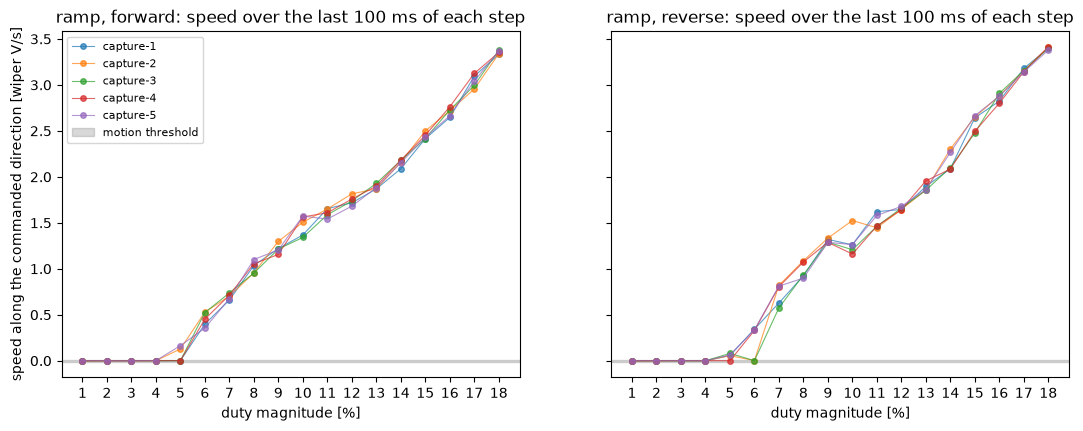

highest still [%]  lowest moving [%]  \
direction capture                                           
forward   capture-1                  5                  6   
          capture-2                  4                  5   
          capture-3                  5                  6   
          capture-4                  5                  6   
          capture-5                  4                  5   
reverse   capture-1                  4                  5   
          capture-2                  6                  5   
          capture-3                  6                  5   
          capture-4                  5                  6   
          capture-5                  4                  5   

                     all moving from [%]  speed at 5% [wiper V/s]  \
direction capture                                                   
forward   capture-1                    6                    0.001   
          capture-2                    5                    0.128   
          capture-3                    6                    0.000   
          capture-4                    6                    0.001   
          capture-5                    5                    0.164   
reverse   capture-1                    5                    0.057   
          capture-2                    7                    0.055   
          capture-3                    7                    0.080   
          capture-4                    6                    0.000   
          capture-5                    5                    0.063   

                     speed at 7% [wiper V/s]  speed at 12% [wiper V/s]  
direction capture                                                       
forward   capture-1                    0.660                     1.718  
          capture-2                    0.702                     1.815  
          capture-3                    0.737                     1.737  
          capture-4                    0.714                     1.758  
          capture-5                    0.675                     1.681  
reverse   capture-1                    0.628                     1.645  
          capture-2                    0.819                     1.645  
          capture-3                    0.574                     1.660  
          capture-4                    0.805                     1.643  
          capture-5                    0.811                     1.679

In [4]:
WIN_100MS = 2000   # samples in the 100 ms judgment window

def baseline_slope_max(recs_list):
    # Largest |slope| over 100 ms windows of the settled baselines.
    worst = 0.0
    for recs in recs_list:
        for df, _ in recs.values():
            base = df[df["seg"] == 0]["pos"].to_numpy() * board.v_adc_per_count
            base = base[len(base) // 5:]
            for k in range(0, len(base) - WIN_100MS, WIN_100MS):
                w = base[k:k + WIN_100MS]
                worst = max(worst, abs(np.polyfit(np.arange(WIN_100MS) / TICK_HZ, w, 1)[0]))
    return worst

MOTION_VPS = 5 * baseline_slope_max([ramp, grid])

def ramp_steps(df):
    out = []
    for seg_id, seg in df[df["seg"] > 0].groupby("seg"):
        d = seg["duty_pct"].iloc[0]
        s = np.sign(d)
        p = seg["pos"].to_numpy() * board.v_adc_per_count
        t = np.arange(WIN_100MS) / TICK_HZ
        # the driven terminal of a step, read with that terminal's own rest reading
        hi, vb = ("vmotor_a", seg["vb"].iloc[0]) if d > 0 else ("vmotor_b", seg["vb_b"].iloc[0])
        out.append({
            "mag_pct": int(round(abs(d))),
            "dir": int(s),
            "head_Vps": np.polyfit(t, p[:WIN_100MS], 1)[0] * s,
            "tail_Vps": np.polyfit(t, p[-WIN_100MS:], 1)[0] * s,
            "current_A": (seg["current_raw"].median() - seg["bias"].iloc[0]) * board.a_per_count,
            "valid_frac": seg["window_valid"].mean(),
            "driven_terminal_V": term_V(seg[hi].median(), vb),
        })
    return pd.DataFrame(out)

ramp_tab = pd.concat([ramp_steps(df).assign(capture=n) for n, (df, _) in ramp.items()])
ramp_tab["moving"] = ramp_tab["tail_Vps"] > MOTION_VPS
SPEED_AT = tuple(p for p in (5, 7, 12) if p <= RAMP_MAX_PCT)   # duty points quoted in the onset table

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, d, label in [(axes[0], 1, "forward"), (axes[1], -1, "reverse")]:
    for name, g in ramp_tab[ramp_tab["dir"] == d].groupby("capture"):
        ax.plot(g["mag_pct"], g["tail_Vps"], "-o", ms=4, lw=0.8, alpha=0.7, label=name)
    ax.axhspan(-MOTION_VPS, MOTION_VPS, color="grey", alpha=0.3, label="motion threshold")
    ax.set_xlabel("duty magnitude [%]")
    ax.set_title(f"ramp, {label}: speed over the last 100 ms of each step")
    ax.set_xticks(range(1, RAMP_MAX_PCT + 1))
axes[0].set_ylabel("speed along the commanded direction [wiper V/s]")
axes[0].legend(fontsize=8)
plt.show()

rows = []
for (name, d), g in ramp_tab.groupby(["capture", "dir"]):
    row = {
        "capture": name,
        "direction": "forward" if d > 0 else "reverse",
        "highest still [%]": g[~g["moving"]]["mag_pct"].max(),
        "lowest moving [%]": g[g["moving"]]["mag_pct"].min(),
        "all moving from [%]": min(m for m in g["mag_pct"] if (g[g["mag_pct"] >= m]["moving"]).all()),
    }
    for pct in SPEED_AT:
        row[f"speed at {pct}% [wiper V/s]"] = g[g["mag_pct"] == pct]["tail_Vps"].iloc[0]
    rows.append(row)
onset = pd.DataFrame(rows).set_index(["direction", "capture"]).sort_index()
onset.round(3)

In [5]:
# Motion threshold, movers per grid point, and the residual motion of the first 100 ms
# against the last 100 ms, pooled over captures.
movers = (ramp_tab.groupby(["dir", "mag_pct"])["moving"].sum().unstack(0)
          .rename(columns={1: f"forward movers of {len(ramp)}", -1: f"reverse movers of {len(ramp)}"}))
speeds = (ramp_tab.groupby(["dir", "mag_pct"])[["head_Vps", "tail_Vps"]].mean().unstack(0))
speeds.columns = [f"{a} {'forward' if b > 0 else 'reverse'}" for a, b in speeds.columns]
out = pd.concat([movers, speeds], axis=1).round(3)
out.index.name = f"duty [%]  (threshold {MOTION_VPS:.4f} wiper V/s)"
out

,reverse movers of 5,forward movers of 5,head_Vps reverse,head_Vps forward,tail_Vps reverse,tail_Vps forward
duty [%] (threshold 0.0111 wiper V/s),,,,,,
1,0,0,-0.116,-0.142,-0.001,-0.001
2,0,0,-0.000,-0.000,-0.000,-0.000
3,0,0,0.001,0.000,0.000,0.000
4,0,0,0.005,0.001,-0.000,0.000
5,4,2,0.037,0.009,0.051,0.059
6,3,5,0.107,0.179,0.203,0.451
7,5,5,0.382,0.485,0.727,0.698
8,5,5,0.328,0.399,0.984,1.020
9,5,5,0.516,0.638,1.303,1.219


Findings:

- The threshold is 0.011 wiper V/s, close to the 0.014 the USB session
  gave and a quarter of the retired battery run's 0.050. It is a property
  of how quietly the mechanism settles, not of the supply that then drives
  it.
- Every step at 4% and below sits inside the threshold in the last 100 ms,
  in both directions, in all five captures. The 1% steps show the residual
  motion of the repositioning move in their first 100 ms and nothing in
  their last 100 ms.
- The first movers are at 5%, two captures of five forward and four of five
  reverse. At 6% it is five forward and three reverse, and from 7% up every
  capture moves in both directions. So the marginal band is two rungs wide,
  5% to 6%, where on USB it was six rungs wide, 9% to 14%.
- A step that breaks away does so decisively: a moving 7% step runs at 0.70
  to 0.73 wiper V/s and a 12% step at 1.65 to 1.74, against a threshold of
  0.011. There is no slow creep in between.
- The capture-to-capture spread that the USB run found (captures 4 and 5
  stiff, capture 1 loose) is not visible here at this resolution, because
  the whole onset now fits in two rungs. Whether it is gone or merely
  hidden below the 1% ladder is open, and section 9 says what a finer
  ladder would show.

The motion onset of this unit lies between 4% and 7% duty in both
directions, with 5% to 6% marginal, and the two directions come out with
the same numbers.

### 5.2 Breakaway voltage

The supply rail comes from the grid recordings, as the median driven
terminal over the valid 20% to 30% steps, the gentlest settled steps, in
corrected terminal volts. Each direction is read on its own terminal with
that terminal's own rest reading. The ramp's own driven terminal above the
voltage floor is shown next to it. The breakaway voltage is the onset duty
times the rail.

In [6]:
def rail_V(df, lo, hi):
    # Supply rail: median driven terminal over the valid drive steps in the duty range,
    # each direction read on its own terminal with that terminal's own rest reading.
    v = df[(df["seg"] > 0) & (df["window_valid"] == 1)
           & (df["mag_pct"] >= lo) & (df["mag_pct"] <= hi)]
    vals = []
    for sel, col, vb in ((v["duty_pct"] > 0, "vmotor_a", "vb"), (v["duty_pct"] < 0, "vmotor_b", "vb_b")):
        if sel.any():
            vals.append(term_V(np.median(v.loc[sel, col]), df[vb].iloc[0]))
    return float(np.mean(vals))

grid_rails = pd.Series({n: rail_V(df, 20, 30) for n, (df, _) in grid.items()})
RAIL_V = grid_rails.mean()
ramp_term = ramp_tab[(ramp_tab["dir"] > 0) & (ramp_tab["mag_pct"] > board.floor_v_pct)]["driven_terminal_V"]

def onset_band(tab):
    # Per direction: the highest rung that sat still in ANY capture, the lowest that moved
    # in any, and the lowest from which every capture moves at that rung and all above it.
    rows = []
    for d, label in ((1, "forward"), (-1, "reverse")):
        g = tab[tab["dir"] == d]
        per = g.groupby("capture")
        still = max(gg[~gg["moving"]]["mag_pct"].max() for _, gg in per)
        low = min(gg[gg["moving"]]["mag_pct"].min() for _, gg in per)
        high = max(min(m for m in gg["mag_pct"] if gg[gg["mag_pct"] >= m]["moving"].all())
                   for _, gg in per)
        rows.append({"direction": label, "still": int(still), "low": int(low), "high": int(high)})
    return pd.DataFrame(rows).set_index("direction")

bands = onset_band(ramp_tab)

rows = []
for label in ["forward", "reverse"]:
    still, low, high = (int(bands.loc[label, k]) for k in ("still", "low", "high"))
    rows.append({
        "direction": label,
        "highest still in any capture [%]": still,
        "moving from [%], marginal": low,
        "moving from [%], every capture": high,
        "highest still in any capture [V]": still / 100 * RAIL_V,
        "breakaway low [V]": low / 100 * RAIL_V,
        "breakaway high [V]": high / 100 * RAIL_V,
    })
break_tab = pd.DataFrame(rows).set_index("direction")
break_tab.insert(0, "rail from grid [V]", RAIL_V)
break_tab.insert(1, "rail spread over captures [V]", grid_rails.max() - grid_rails.min())
break_tab.insert(2, f"ramp terminal above {board.floor_v_pct:.0f}% forward [V]", ramp_term.mean())
break_tab.round(3).T

direction,forward,reverse
rail from grid [V],7.761,7.761
rail spread over captures [V],0.107,0.107
ramp terminal above 13% forward [V],7.576,7.576
highest still in any capture [%],5.000,6.000
"moving from [%], marginal",5.000,5.000
"moving from [%], every capture",6.000,7.000
highest still in any capture [V],0.388,0.466
breakaway low [V],0.388,0.388
breakaway high [V],0.466,0.543


The rail is 7.76 V with a spread of 0.11 V across the ten grid captures,
and the ramp's forward driven terminal above the voltage floor reads
7.58 V, 0.19 V lower. That is the opposite sign from USB, where the ramp
read *higher* than the grid because the grid steps drew more current and
sagged the supply. On 2S the rail rises slightly with load rather than
falling (notebook 03, section 5.1), so the gentler ramp reads lower. Either
way the difference is 2.4% and I use the grid rail.

**The breakaway voltage band is 0.39 to 0.54 V.** Its lower edge, the
first rung that moved in any capture, is 0.39 V (5% duty) in both
directions. Its upper edge, the rung from which every capture moves, is
0.47 V (6%) forward and 0.54 V (7%) reverse, so the two directions differ
by one rung. The highest duty that sat still in *every* capture is 4%,
0.31 V.

Against the two retired runs:

- The retired battery run, on the previous chain, gave 0.37 to 0.51 V. This
  run agrees with it to within 6% at both ends. Two batteries, two chains,
  one mechanism, and the answer repeats.
- The USB run reported 0.41 to 0.68 V, a band three times wider. Its lower
  edge agrees with both battery runs; its upper edge does not. That width
  was the supply: at 4.5 V the onset sat at 9 to 15% duty, where a one-point
  ladder step is 0.046 V, and the rail sagged as the mechanism began to
  move, so a rung that broke away at one moment did not at another. Section
  5.4 re-derives the USB band with this notebook's own criterion and gets a
  narrower 0.32 to 0.55 V, which is the criterion difference, not new data.

The reading that survives all three runs is the **lower** edge, 0.32 to
0.41 V, which is where the mechanism first moves at all. The upper edge is
where it moves reliably, and that is the number a supply and a criterion
can both spoil.

### 5.3 The current at the onset

The crest-scan current of every ramp step is shown below, bias subtracted.
The rungs inside the grey band are under the current floor, so they are
unsettled amplifier outputs and no quantity is fitted on them. From 14% up
the samples are settled, and there the ramp reads 64 to 68 mA at 14% and
70 to 76 mA at 18%, well above breakaway in both cases. Section 6.1 finds
the Coulomb intercept of the drive current at 46 to 56 mA.

The breakaway current itself still has to be model-derived, as the
breakaway voltage divided by the winding resistance, which assumes the
motor is at rest with no back-EMF at the moment of breakaway. The onset
sits at 5 to 7% duty and the current floor at 13.3%, so the whole onset
band is below it, and this ladder cannot reach it directly on any supply
that breaks away this early. The resistance is notebook 03's input, and the
spread column carries the union of the registry bracket and the 2S re-run's.

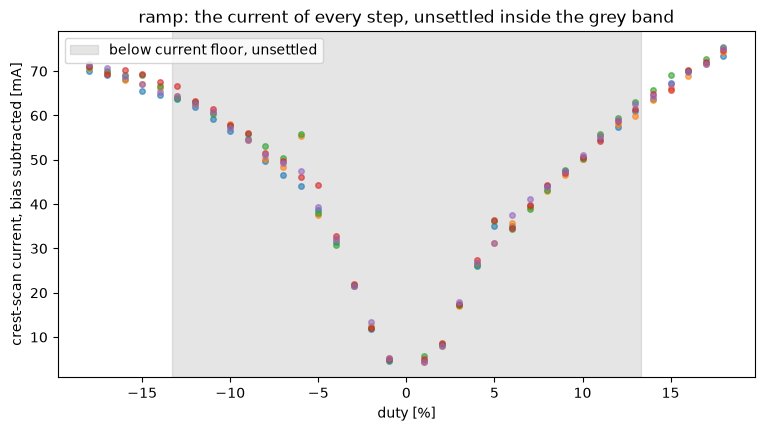

,value,spread,source
quantity,,,
unsettled crest current at 1% [mA],4.429,1.256,"ramp, both directions"
unsettled crest current at 13% [mA],59.930,6.811,"ramp, both directions"
settled crest current at 14% [mA],63.511,4.125,"ramp, above the current floor"
settled crest current at 18% [mA],69.939,5.570,"ramp, above the current floor"
winding resistance [Ohm],4.500,0.790,"nb03, full duty onset anchor (input), bracket ..."
"breakaway current, forward, low [A], model-derived",0.086,0.016,breakaway voltage / R
"breakaway current, forward, high [A], model-derived",0.103,0.019,breakaway voltage / R
"breakaway current, reverse, low [A], model-derived",0.086,0.016,breakaway voltage / R
"breakaway current, reverse, high [A], model-derived",0.121,0.022,breakaway voltage / R


In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for name, g in ramp_tab.groupby("capture"):
    ax.plot(g["mag_pct"] * g["dir"], g["current_A"] * 1e3, "o", ms=4, alpha=0.6)
ax.axvspan(-board.floor_i_pct, board.floor_i_pct, color="grey", alpha=0.2,
           label="below current floor, unsettled")
ax.set_xlabel("duty [%]")
ax.set_ylabel("crest-scan current, bias subtracted [mA]")
ax.set_title("ramp: the current of every step, unsettled inside the grey band")
ax.legend()
plt.show()

cur = ramp_tab.groupby("mag_pct")["current_A"].agg(["min", "max"]) * 1e3
settled_lo = int(np.ceil(board.floor_i_pct))
rows = [
    {"quantity": "unsettled crest current at 1% [mA]", "value": cur.loc[1, "min"],
     "spread": cur.loc[1, "max"] - cur.loc[1, "min"], "source": "ramp, both directions"},
    {"quantity": f"unsettled crest current at {settled_lo - 1}% [mA]", "value": cur.loc[settled_lo - 1, "min"],
     "spread": cur.loc[settled_lo - 1, "max"] - cur.loc[settled_lo - 1, "min"], "source": "ramp, both directions"},
    {"quantity": f"settled crest current at {settled_lo}% [mA]", "value": cur.loc[settled_lo, "min"],
     "spread": cur.loc[settled_lo, "max"] - cur.loc[settled_lo, "min"], "source": "ramp, above the current floor"},
    {"quantity": f"settled crest current at {RAMP_MAX_PCT}% [mA]", "value": cur.loc[RAMP_MAX_PCT, "min"],
     "spread": cur.loc[RAMP_MAX_PCT, "max"] - cur.loc[RAMP_MAX_PCT, "min"], "source": "ramp, above the current floor"},
    {"quantity": "winding resistance [Ohm]", "value": R_WINDING_OHM,
     "spread": R_WINDING_HI - R_WINDING_LO, "source": f"{R_W.source} (input), bracket widened by the 2S re-run"},
]
for label in ["forward", "reverse"]:
    for edge, key in (("low", "breakaway low [V]"), ("high", "breakaway high [V]")):
        v = break_tab.loc[label, key]
        rows.append({"quantity": f"breakaway current, {label}, {edge} [A], model-derived",
                     "value": v / R_WINDING_OHM,
                     "spread": v * (1 / R_WINDING_LO - 1 / R_WINDING_HI),
                     "source": "breakaway voltage / R"})
pd.DataFrame(rows).set_index("quantity").round(3)

With 4.5 Ohm the breakaway current is 0.086 to 0.121 A, model-derived, and
the resistance bracket moves each end by about 0.02 A. Section 6.1 finds
the Coulomb intercept of the drive current at 0.046 to 0.056 A, so the
current at breakaway exceeds the Coulomb current at speed by a factor of
1.5 to 2.6. The USB run put that factor at 3 to 5 and the retired battery
run at 2 to 3.

The factor is coming down as the supply gets stiffer, and that is a warning
about what it measures. Every one of those figures is a breakaway *voltage*
divided by a resistance, and the breakaway voltage on a sagging supply is
overstated, because the rung that finally moved the mechanism did so with
its rail already pulled down. This run's 1.5 to 2.6 is the least
supply-contaminated of the three, and it still rests on a resistance in
dispute.

*Hypothesis (not tested here): static friction exceeds kinetic friction in
this gear train, as is usual for lubricated metal and plastic contacts. The
settled rungs at 14 to 18% give a real current a factor of three above
breakaway, but not at the onset itself. A finer ladder cannot help on this
supply, since the onset is below the current floor at any duty resolution.
Section 9 names what would.*

### 5.4 USB as a trend check

The breakaway duty is the one number in this notebook that a supply is
expected to move, so USB is worth one look: at a rail two thirds lower, the
same mechanism should need roughly the same *voltage* and therefore roughly
5/7.76 as much *duty*. This is a trend check, not a source.

In [8]:
ds_usb = oscnb.use("sg90-a__dev-v006-D__usb", show=False)
ramp_usb = load_series(ds_usb, "breakaway", "sweep")
grid_usb = load_series(ds_usb, "grid", "sweep")

usb_tab = pd.concat([ramp_steps(df).assign(capture=n) for n, (df, _) in ramp_usb.items()])
usb_tab["moving"] = usb_tab["tail_Vps"] > MOTION_VPS
usb_rail = np.mean([rail_V(df, 20, 30) for df, _ in grid_usb.values()])
usb_bands = onset_band(usb_tab)

rows = []
for label, b, rail in (("2s", bands, RAIL_V), ("usb", usb_bands, usb_rail)):
    for direction in ("forward", "reverse"):
        low, high = int(b.loc[direction, "low"]), int(b.loc[direction, "high"])
        rows.append({"supply": label, "direction": direction, "rail [V]": rail,
                     "first mover [% duty]": low, "every capture moving from [% duty]": high,
                     "breakaway low [V]": low / 100 * rail,
                     "breakaway high [V]": high / 100 * rail})
supply_cmp = pd.DataFrame(rows).set_index(["supply", "direction"])
supply_cmp["duty ratio vs 2s"] = supply_cmp["first mover [% duty]"] / \
    supply_cmp.xs("2s", level="supply")["first mover [% duty]"].reindex(
        supply_cmp.index.get_level_values("direction")).to_numpy()
display(supply_cmp.round(3))

# put the primary dataset back before anything else runs
ds = oscnb.use("sg90-a__dev-v006-D__2s", show=False)
board, servo = oscnb.current().board, oscnb.current().servo

rail [V]  first mover [% duty]  \
supply direction                                   
2s     forward       7.761                     5   
       reverse       7.761                     5   
usb    forward       4.617                     8   
       reverse       4.617                     7   

                  every capture moving from [% duty]  breakaway low [V]  \
supply direction                                                          
2s     forward                                     6              0.388   
       reverse                                     7              0.388   
usb    forward                                    12              0.369   
       reverse                                    11              0.323   

                  breakaway high [V]  duty ratio vs 2s  
supply direction                                        
2s     forward                 0.466               1.0  
       reverse                 0.543               1.0  
usb    forward                 0.554               1.6  
       reverse                 0.508               1.4

The duty moves and the voltage roughly does not, which is the expected
trend. USB first moves at 8% forward and 7% reverse of a 4.62 V rail, 2S at
5% of a 7.76 V rail. If the mechanism needed exactly one voltage the USB
duty would be the rail ratio 7.76 / 4.62 = 1.68 times the 2S duty. The last
column reads 1.6 forward and 1.4 reverse, so a single breakaway voltage
accounts for most of the move and the ladder's 1% quantisation covers the
rest.

In volts: USB's lower edge is 0.37 V forward and 0.32 V reverse against 2S's
0.39 V in both, so the two supplies agree on where the mechanism first moves
to within 0.07 V. The upper edge is where they part, 0.55 and 0.51 V on USB
against 0.47 and 0.54 V on 2S, with no consistent sign, which is what a
rung-quantised criterion on a sagging rail produces.

Nothing above is fitted to USB.

## 6. Friction at speed

### 6.1 Route B, steady-state current against speed

For every grid step at or above the 15% grid point (the first above the
current floor) two quantities are needed, the steady speed and the steady
current. The reference estimate of each follows notebook 00 and uses the
last 60% of the step. The speed is the slope of a line through the
position, and the current is the median of the crest-scan samples.

The retired 80 ms grid did not settle: its steps were about four
mechanical time constants long and the reference window still carried 15 to
45% of transient. **The travel-sized windows of this dataset do settle.**
Each step is nevertheless fitted with

$$i(t) = i_{ss} + A\,e^{-t/\tau},$$

which gives the steady current $i_{ss}$ by extrapolation and $\tau$ as a
quality flag, so the correction is measured rather than assumed. The speed
uses the same model. With $\tau$ fixed from the current fit, the position
over the same window is fitted with

$$p(t) = p_0 + v_{ss}\,t - (v_{ss} - v_0)\,\tau\,(1 - e^{-t/\tau}),$$

linear in $(p_0, v_{ss}, v_0)$, which averages the pot ripple over the
whole window. Two quality flags follow, the remaining transient in the
reference window (how far the last-60% current sits above the extrapolated
steady value) and the residual acceleration at the end of the step.

Route A's coast segments enter at speeds up to about 8.5 wiper V/s
(section 6.2). The like-for-like comparison of section 7 therefore fits
route B on steps whose steady speed lies inside route A's own range, and
that ceiling is **taken from route A's fitted entry speeds** rather than
written down. The fit is repeated on an extended range and on the full
range, to show how the line depends on the range.

In [9]:
SKIP = 200        # first 10 ms of each step excluded from the fits
REF_FRAC = 0.4    # the reference window starts at 40% of the step (notebook 00)

def i_model(t, i_ss, A, tau):
    return i_ss + A * np.exp(-t / tau)

def grid_steps(df):
    out = []
    lo = int(np.ceil(board.floor_i_pct / 5) * 5)      # first 5% grid point above the current floor
    for seg_id, seg in df[(df["seg"] > 0) & (df["mag_pct"] >= lo)].groupby("seg"):
        d = seg["duty_pct"].iloc[0]
        s = np.sign(d)
        n = len(seg)
        p = seg["pos"].to_numpy() * board.v_adc_per_count * s
        cur = (seg["current_raw"].to_numpy() - seg["bias"].iloc[0]) * board.a_per_count
        ok = seg["window_valid"].to_numpy() == 1
        ref = slice(int(n * REF_FRAC), n)
        v_ref = np.polyfit(np.arange(n - ref.start) / TICK_HZ, p[ref], 1)[0]
        i_ref = np.median(cur[ref][ok[ref]])
        t = np.arange(n - SKIP) / TICK_HZ
        c, tc = cur[SKIP:][ok[SKIP:]], t[ok[SKIP:]]
        (i_ss, A, tau), _ = curve_fit(i_model, tc, c, p0=[c[-1], c[0] - c[-1], 0.02],
                                      bounds=([0, -np.inf, 0.002], [np.inf, np.inf, 0.5]))
        g = tau * (1 - np.exp(-t / tau))
        X = np.column_stack([np.ones_like(t), t - g, g])
        p0, v_ss, v0 = np.linalg.lstsq(X, p[SKIP:], rcond=None)[0]
        out.append({
            "mag_pct": int(round(abs(d))), "dir": int(s),
            "v_ref_Vps": v_ref, "i_ref_A": i_ref,
            "v_ss_Vps": v_ss, "i_ss_A": i_ss, "tau_ms": tau * 1e3,
            "step_ms": n / TICK_HZ * 1e3, "taus_per_step": (n / TICK_HZ) / tau,
            "transient_pct": (i_ref - i_ss) / i_ss * 100,
            "accel_end_Vps2": (v_ss - v0) / tau * np.exp(-t[-1] / tau),
            "pos_V": np.median(p[ref]) * s,
        })
    return pd.DataFrame(out)

grid_tab = pd.concat([grid_steps(df).assign(capture=n) for n, (df, _) in grid.items()])
print(f"grid steps fitted: {len(grid_tab)} over {len(grid)} captures")
grid_tab.head()

grid steps fitted: 360 over 10 captures


,mag_pct,dir,v_ref_Vps,i_ref_A,v_ss_Vps,i_ss_A,tau_ms,step_ms,taus_per_step,transient_pct,accel_end_Vps2,pos_V,capture
0,15,1,2.497211,0.065450,2.518788,0.066122,18.975815,842.0,44.372270,-1.016499,1.134229e-18,1.782129,capture-1
1,20,1,3.692755,0.074402,3.708187,0.076267,18.196942,590.0,32.423029,-2.445185,1.909430e-12,1.819995,capture-1
2,25,1,4.885025,0.081563,4.916933,0.083986,19.511846,458.0,23.472921,-2.884312,1.341301e-08,1.776489,capture-1
3,30,1,6.148517,0.085144,6.148189,0.088216,19.771162,376.0,19.017597,-3.482364,1.887893e-06,1.844971,capture-1
4,35,1,7.371679,0.090515,7.367432,0.093260,20.390924,320.0,15.693257,-2.942979,5.314009e-05,1.819995,capture-1


### 6.2 Route A, coast deceleration against speed

The coast segments of the spin-down recordings decelerate under friction
alone. Notebook 01 fitted the model

$$\frac{dv}{dt} = -(a + b\,v), \qquad v > 0,$$

to the back-EMF $e = V_a - V_b$ of every coast segment, less the rest split
of the two terminals, taken positive along the entry direction, with one
$(a, b)$ per recording and one entry value per segment. The first three
samples of each coast are excluded, and so is any sample where the terminal
sum exceeds the rail (the diode phase). The EMF stands in for speed, and
$a$ is converted to wiper units with the EMF-to-speed slope from the
integral of the EMF over the travel of each segment. The same fit is
repeated here on the same data so that the numbers of the two notebooks
agree by construction. The rail of each recording is the median driven
terminal over its valid drive steps at 20% to 40%.

Notebook 03 has since shown that this EMF-to-speed slope is not the motor's
$K_e$: it is $K_e$ divided by whatever the pot reports, and just after the
bridge opens the pot reports the output running on through the gear
backlash while the motor slows. That does not touch route A's *ratio*
$a/b$, which is what section 7 tests, because the slope divides out of it.
It does touch $a$ and $b$ individually, and section 9 carries that.

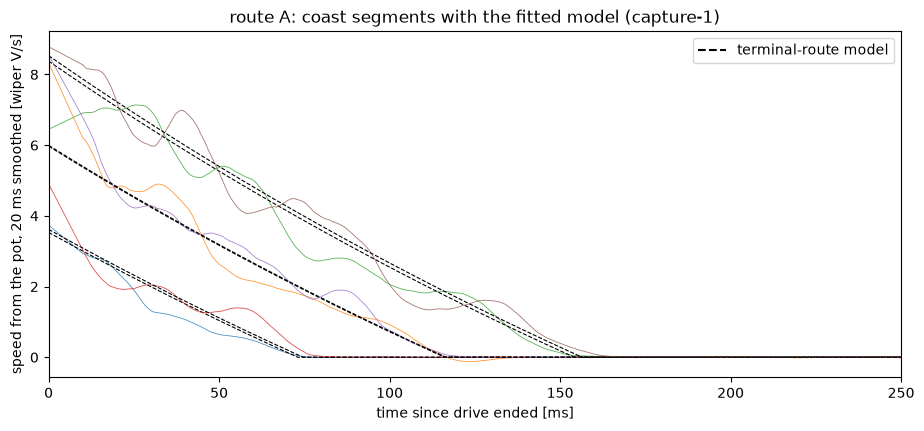

route A entry speeds reach 8.53 wiper V/s  ->  matched range <= 9.0, extended <= 13.5


,EMF slope [V per wiper V/s],a [wiper V/s2],b [1/s],b se [1/s],a/b [wiper V/s],rms resid [mV],entry speed min [wiper V/s],entry speed max [wiper V/s]
mean,0.289,40.720,2.761,0.042,14.765,63.710,3.490,8.302
min,0.283,39.425,2.633,0.041,13.786,61.742,3.415,8.144
max,0.294,43.653,2.887,0.043,15.898,64.803,3.556,8.532


In [10]:
FIT_N = 5000    # 250 ms of every coast segment enters the fit
SG_WIN = 401    # 20 ms smoothing window for speed from the pot
COAST_SKIP = 3  # samples excluded at the start of every coast segment

spin_rails = {n: rail_V(df, 20, 40) for n, (df, _) in spin.items()}

def coast_segments(df):
    # Per coast segment: position and EMF vA - vB positive along the entry direction, the
    # terminal sum for the diode-phase mask, all in V.
    out = []
    for seg_id, seg in df[df["kind"] == "coast"].groupby("seg"):
        d = int(seg["dir"].iloc[0])
        vb, vb_b = seg["vb"].iloc[0], seg["vb_b"].iloc[0]
        vA, vB = term_V(seg["vmotor_a"].to_numpy(), vb), term_V(seg["vmotor_b"].to_numpy(), vb_b)
        out.append({
            "seg": seg_id, "dir": d,
            "entry_pct": int(df.loc[df["seg"] == seg_id - 1, "mag_pct"].iloc[0]),
            "p": seg["pos"].to_numpy() * d * board.v_adc_per_count,
            "e": (vA - vB) * d,
            "sum": vA + vB,
        })
    return out

def coast_mask(c, rail):
    i = np.arange(len(c["e"]))
    return (i >= COAST_SKIP) & (c["sum"] < rail)

def speed_model(t, v0, a, b):
    a, b = max(a, 1e-6), max(b, 1e-6)
    t_stop = np.log1p(b * v0 / a) / b
    return np.where(t < t_stop, (v0 + a / b) * np.exp(-b * np.minimum(t, t_stop)) - a / b, 0.0)

def terminal_fit(segs, rail):
    # Shared (a, b) in EMF units, one entry value per segment.
    t = np.arange(FIT_N) / TICK_HZ
    masks = [coast_mask(c, rail)[:FIT_N] for c in segs]
    def resid(x):
        return np.concatenate([(speed_model(t, x[2 + i], x[0], x[1]) - c["e"][:FIT_N])[m]
                               for i, (c, m) in enumerate(zip(segs, masks))])
    x0 = [30.0, 5.0] + [max(c["e"][COAST_SKIP], 0.1) for c in segs]
    lb = [0.0, 0.0] + [0.0] * len(segs)
    res = least_squares(resid, x0, bounds=(lb, np.inf))
    dof = len(res.fun) - len(res.x)
    cov = np.linalg.inv(res.jac.T @ res.jac) * np.sum(res.fun ** 2) / dof
    return {"a": res.x[0], "b": res.x[1], "b_se": np.sqrt(cov[1, 1]), "starts": res.x[2:],
            "rms_resid": np.sqrt(np.mean(res.fun ** 2))}

def terminal_slope(segs, rail):
    # EMF integral over the segment divided by the travel: V per wiper V/s.
    ratios = []
    for c in segs:
        m = coast_mask(c, rail)
        travel = np.median(c["p"][-1000:]) - np.median(c["p"][:COAST_SKIP])
        ratios.append(np.sum(c["e"][m]) / TICK_HZ / travel)
    return np.mean(ratios)

coast_fits = {}
for name, (df, _) in spin.items():
    segs = coast_segments(df)
    slope = terminal_slope(segs, spin_rails[name])
    f = terminal_fit(segs, spin_rails[name])
    coast_fits[name] = {"segs": segs, "slope": slope, "a": f["a"] / slope, "b": f["b"],
                        "b_se": f["b_se"], "starts": f["starts"] / slope,
                        "rms_resid": f["rms_resid"]}

fig, ax = plt.subplots(figsize=(11, 4.5))
name, f = next(iter(coast_fits.items()))
t = np.arange(FIT_N) / TICK_HZ
for i, c in enumerate(f["segs"]):
    v = savgol_filter(c["p"][:FIT_N], SG_WIN, 2, deriv=1, delta=1 / TICK_HZ)
    ax.plot(t * 1e3, v, lw=0.6, alpha=0.8)
    ax.plot(t * 1e3, speed_model(t, f["starts"][i], f["a"], f["b"]), "k--", lw=0.8)
ax.plot([], [], "k--", label="terminal-route model")
ax.set_xlim(0, 250)
ax.set_xlabel("time since drive ended [ms]")
ax.set_ylabel("speed from the pot, 20 ms smoothed [wiper V/s]")
ax.set_title(f"route A: coast segments with the fitted model ({name})")
ax.legend()
plt.show()

route_a = pd.DataFrame([{
    "capture": n, "EMF slope [V per wiper V/s]": f["slope"],
    "a [wiper V/s2]": f["a"], "b [1/s]": f["b"], "b se [1/s]": f["b_se"],
    "a/b [wiper V/s]": f["a"] / f["b"], "rms resid [mV]": f["rms_resid"] * 1e3,
    "entry speed min [wiper V/s]": f["starts"].min(), "entry speed max [wiper V/s]": f["starts"].max(),
} for n, f in coast_fits.items()]).set_index("capture")

# Route A's own reach sets route B's matched range. No magic ceiling.
V_MATCH = float(np.ceil(route_a["entry speed max [wiper V/s]"].max() * 2) / 2)
V_EXT = float(np.ceil(V_MATCH * 1.5 * 2) / 2)
print(f"route A entry speeds reach {route_a['entry speed max [wiper V/s]'].max():.2f} wiper V/s"
      f"  ->  matched range <= {V_MATCH}, extended <= {V_EXT}")
route_a.agg(["mean", "min", "max"]).round(3)

In [11]:
# The same fit per direction, with the recording's EMF slope.
rows = []
for name, f in coast_fits.items():
    for d, label in [(1, "forward"), (-1, "reverse")]:
        segs = [c for c in f["segs"] if c["dir"] == d]
        ff = terminal_fit(segs, spin_rails[name])
        rows.append({"direction": label, "capture": name,
                     "a [wiper V/s2]": ff["a"] / f["slope"], "b [1/s]": ff["b"],
                     "a/b [wiper V/s]": ff["a"] / f["slope"] / ff["b"]})
route_a_dir = pd.DataFrame(rows).groupby("direction")[["a [wiper V/s2]", "b [1/s]", "a/b [wiper V/s]"]]
route_a_dir.agg(["mean", "min", "max"]).round(3)

a [wiper V/s2]                 b [1/s]                \
                    mean     min     max    mean    min    max   
direction                                                        
forward           41.279  40.208  44.211   2.895  2.789  3.051   
reverse           40.067  38.622  42.949   2.672  2.509  2.777   

          a/b [wiper V/s]                  
                     mean     min     max  
direction                                  
forward            14.275  13.179  15.353  
reverse            15.020  13.908  16.125

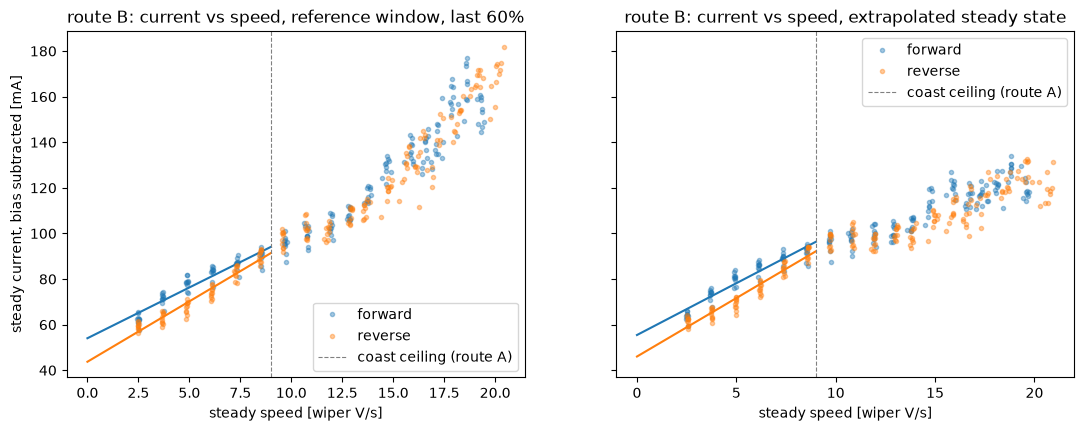

i_c [A]  \
method                     range             direction            
reference window, last 60% matched, <= 9.0   forward     0.0540   
                           extended, <= 13.5 forward     0.0557   
                           full              forward     0.0449   
                           matched, <= 9.0   reverse     0.0437   
                           extended, <= 13.5 reverse     0.0456   
                           full              reverse     0.0372   
extrapolated steady state  matched, <= 9.0   forward     0.0555   
                           extended, <= 13.5 forward     0.0615   
                           full              forward     0.0623   
                           matched, <= 9.0   reverse     0.0460   
                           extended, <= 13.5 reverse     0.0515   
                           full              reverse     0.0562   

                                                        i_v [A per wiper V/s]  \
method                     range             direction                          
reference window, last 60% matched, <= 9.0   forward                   0.0045   
                           extended, <= 13.5 forward                   0.0041   
                           full              forward                   0.0057   
                           matched, <= 9.0   reverse                   0.0053   
                           extended, <= 13.5 reverse                   0.0050   
                           full              reverse                   0.0061   
extrapolated steady state  matched, <= 9.0   forward                   0.0045   
                           extended, <= 13.5 forward                   0.0033   
                           full              forward                   0.0033   
                           matched, <= 9.0   reverse                   0.0051   
                           extended, <= 13.5 reverse                   0.0041   
                           full              reverse                   0.0034   

                                                        ratio [wiper V/s]  \
method                     range             direction                      
reference window, last 60% matched, <= 9.0   forward              12.1401   
                           extended, <= 13.5 forward              13.5634   
                           full              forward               7.9238   
                           matched, <= 9.0   reverse               8.2553   
                           extended, <= 13.5 reverse               9.1342   
                           full              reverse               6.1333   
extrapolated steady state  matched, <= 9.0   forward              12.2075   
                           extended, <= 13.5 forward              18.4070   
                           full              forward              19.1557   
                           matched, <= 9.0   reverse               8.9738   
                           extended, <= 13.5 reverse              12.5177   
                           full              reverse              16.5041   

                                                        ratio min  ratio max  \
method                     range             direction                         
reference window, last 60% matched, <= 9.0   forward      10.9027    13.3618   
                           extended, <= 13.5 forward      11.9333    14.8401   
                           full              forward       6.9045    10.2802   
                           matched, <= 9.0   reverse       7.6969     8.8861   
                           extended, <= 13.5 reverse       8.2243    10.0729   
                           full              reverse       5.4309     6.9231   
extrapolated steady state  matched, <= 9.0   forward      11.5757    13.1064   
                           extended, <= 13.5 forward      16.1090    20.4461   
                           full              forward      16.3107    22.4421   
                       

In [12]:
def line_fit(tab, vcol, icol):
    k = np.polyfit(tab[vcol], tab[icol], 1)
    per = []
    for _, g in tab.groupby("capture"):
        kk = np.polyfit(g[vcol], g[icol], 1)
        per.append(kk[1] / kk[0])
    return {"i_c [A]": k[1], "i_v [A per wiper V/s]": k[0], "ratio [wiper V/s]": k[1] / k[0],
            "ratio min": min(per), "ratio max": max(per), "steps": len(tab)}

ranges = [(f"matched, <= {V_MATCH}", V_MATCH), (f"extended, <= {V_EXT}", V_EXT), ("full", np.inf)]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
vv = np.linspace(0, V_MATCH, 50)
fits = []
for ax, vcol, icol, title in [(axes[0], "v_ref_Vps", "i_ref_A", "reference window, last 60%"),
                              (axes[1], "v_ss_Vps", "i_ss_A", "extrapolated steady state")]:
    for d, color, label in [(1, "tab:blue", "forward"), (-1, "tab:orange", "reverse")]:
        g = grid_tab[grid_tab["dir"] == d]
        ax.plot(g[vcol], g[icol] * 1e3, "o", ms=3, alpha=0.4, color=color, label=label)
        for rname, vmax in ranges:
            f = line_fit(g[g[vcol] <= vmax], vcol, icol)
            fits.append({"method": title, "range": rname, "direction": label, **f})
            if vmax == V_MATCH:
                ax.plot(vv, (f["i_c [A]"] + f["i_v [A per wiper V/s]"] * vv) * 1e3, "-",
                        color=color, lw=1.5)
    ax.axvline(V_MATCH, color="grey", lw=0.8, ls="--", label="coast ceiling (route A)")
    ax.set_xlabel("steady speed [wiper V/s]")
    ax.set_title(f"route B: current vs speed, {title}")
    ax.legend()
axes[0].set_ylabel("steady current, bias subtracted [mA]")
plt.show()

route_b = pd.DataFrame(fits).set_index(["method", "range", "direction"])
route_b.round(4)

In [13]:
# Quality flags by grid point, mean over captures: step length in time constants, remaining
# transient in the reference window, residual acceleration at the end of the step.
q = (grid_tab.groupby(["dir", "mag_pct"])[["v_ss_Vps", "i_ss_A", "tau_ms", "step_ms",
                                           "taus_per_step", "transient_pct", "accel_end_Vps2"]]
     .mean().unstack(0))
q.columns = [f"{a} {'fwd' if b > 0 else 'rev'}" for a, b in q.columns]
q[[c for c in q.columns if "fwd" in c] + [c for c in q.columns if "rev" in c]].round(3)

,v_ss_Vps fwd,i_ss_A fwd,tau_ms fwd,step_ms fwd,taus_per_step fwd,transient_pct fwd,accel_end_Vps2 fwd,v_ss_Vps rev,i_ss_A rev,tau_ms rev,step_ms rev,taus_per_step rev,transient_pct rev,accel_end_Vps2 rev
mag_pct,,,,,,,,,,,,,,
15,2.514,0.064,18.392,842.0,45.831,-2.311,0.000,2.552,0.061,19.348,842.0,43.594,-3.702,0.000
20,3.702,0.073,18.734,590.0,31.502,-2.481,0.000,3.759,0.065,20.037,590.0,29.462,-3.174,0.000
25,4.911,0.080,19.585,458.0,23.387,-2.719,0.000,4.969,0.069,20.502,458.0,22.346,-2.471,0.000
30,6.129,0.085,20.121,376.0,18.688,-2.619,0.000,6.192,0.076,21.014,376.0,17.893,-2.398,0.000
35,7.348,0.089,20.426,320.0,15.667,-2.661,0.000,7.391,0.085,20.933,320.0,15.288,-2.134,0.000
40,8.531,0.092,20.569,280.0,13.614,-1.885,0.000,8.593,0.092,21.174,280.0,13.225,-1.546,0.001
45,9.696,0.096,20.471,250.0,12.214,-0.985,0.003,9.716,0.097,21.093,250.0,11.854,0.656,0.003
50,10.765,0.098,20.437,226.0,11.061,2.270,0.009,10.860,0.099,20.832,226.0,10.852,3.008,0.010
55,11.935,0.100,20.279,207.0,10.211,3.828,0.024,11.925,0.096,21.158,207.0,9.784,4.946,0.029


Findings:

- The mechanical time constant under drive is 17.7 to 21.2 ms, flat across
  the grid, where the retired battery run read 17 to 21 and the USB run 18 to
  25 rising with duty.
- **The steps settle.** The travel-sized windows run 6 time constants at
  100% duty and 40 or more at the low rungs, so the remaining transient in
  the reference window is *negative* below 45% duty, -1.5 to -3.7%, which
  is the pot ripple and not a transient at all. It first turns positive at
  45% reverse and 50% forward, and reaches 28 to 41% at 100%, where the
  window is shortest.
  The retired 80 ms grid carried 15 to 23% of transient at 20 to 30% duty,
  and correcting it was most of what route B's extrapolation did. In the
  matched range it now corrects a few percent.
- The residual acceleration at the end of the step is at most 0.001 wiper
  V/s$^2$ everywhere in the matched range and reaches 0.75 to 2.0 only at
  the 95 and 100% points.
- In the matched range the line through the extrapolated values gives $i_c$
  of 0.0555 A forward and 0.0460 A reverse, $i_v$ of 0.0045 and 0.0051 A
  per wiper V/s, and ratios of 12.21 and 8.97 wiper V/s, with
  per-capture ratio spreads of 11.6 to 13.1 and 8.5 to 9.6. The direction
  asymmetry is 19% in $i_c$ and 13% in $i_v$, of opposite sign, so it
  compounds into 31% in the ratio.
- The line still depends on the range. Extending it to 13.5 wiper V/s moves
  the ratios to 18.4 and 12.5, and the full-range line gives 19.2 and 16.5.
  The curvature is in the current: the extrapolated steady current runs from
  58 mA at the 15% rung to 134 mA at the top, and it does not rise
  linearly. It is nearly flat from 45% to 65% duty and climbs again above
  it.
- The reference-window values give nearly the same matched-range line as
  the extrapolated ones, 12.14 and 8.26 against 12.21 and 8.97, which is
  the settling above restated: on the 80 ms grid the two differed by a
  factor of two.

Route A findings:

- The EMF slope is 0.289 V per wiper V/s (0.283 to 0.294), the Coulomb term
  40.7 wiper V/s$^2$ (39.4 to 43.7) and the viscous term 2.76 1/s (2.63 to
  2.89). The ratio $a / b$ is 14.77 wiper V/s with a spread of 13.79 to
  15.90 across the five captures.
- Against the retired runs: the battery run gave 34.4, 3.00 and 11.5, and
  the USB run 31.3, 4.44 and 7.08. The Coulomb term is now 18% above the
  retired battery figure and 30% above USB, and the viscous term is 8%
  below the battery figure and 38% below USB. The crossover moved from 7.08
  to 14.77.
- That is a large move, and the range is why. The coast entries reach 8.5
  wiper V/s here against 4.6 on USB, so route A now sees nearly twice the
  span of speed it had, and the split between a constant term and a
  proportional one is exactly what a wider span buys. The USB fit was
  reading curvature over a narrow range; whether this one still is, is
  section 9's problem, not a settled matter.
- Per direction, $a$ is 41.3 forward and 40.1 reverse and $b$ is 2.90 and
  2.67, an asymmetry of 3% in $a$ and 8% in $b$ of opposite sign, so the
  ratio is 14.28 forward and 15.02 reverse with overlapping spreads. Route
  A sees essentially no direction asymmetry. Route B sees 31%. Section 7
  makes that the headline.
- The ratio $a / b$ still lies above the fitted range, 14.8 against entries
  that reach 8.5, so at the top of the range the viscous term is still only
  three fifths of the Coulomb term and the split rests on curvature within
  the range.

## 7. Agreement of the two routes

The ratio $\tau_c / b_v$ is the speed at which viscous friction equals
Coulomb friction. Route A gives it as $a / b$ and route B as $i_c / i_v$,
with no inertia or torque constant involved. The table sets the two side by
side, route B in the matched speed range with the extrapolated steady
values (section 6.1), and the extended range and the reference-window
values for comparison.

In [14]:
ra = route_a["a/b [wiper V/s]"]
rows = [{"route": "A, coast", "direction": "both", "ratio [wiper V/s]": ra.mean(),
         "min": ra.min(), "max": ra.max(), "vs route A [%]": 0.0}]
for method, rname in [("extrapolated steady state", f"matched, <= {V_MATCH}"),
                      ("extrapolated steady state", f"extended, <= {V_EXT}"),
                      ("reference window, last 60%", f"matched, <= {V_MATCH}")]:
    for direction in ["forward", "reverse"]:
        f = route_b.loc[(method, rname, direction)]
        rows.append({"route": f"B, drive, {method}, {rname}", "direction": direction,
                     "ratio [wiper V/s]": f["ratio [wiper V/s]"], "min": f["ratio min"],
                     "max": f["ratio max"],
                     "vs route A [%]": (f["ratio [wiper V/s]"] / ra.mean() - 1) * 100})
agree = pd.DataFrame(rows).set_index(["route", "direction"])
agree.round(2)

ratio [wiper V/s]  \
route                                              direction                      
A, coast                                           both                   14.77   
B, drive, extrapolated steady state, matched, <... forward                12.21   
                                                   reverse                 8.97   
B, drive, extrapolated steady state, extended, ... forward                18.41   
                                                   reverse                12.52   
B, drive, reference window, last 60%, matched, ... forward                12.14   
                                                   reverse                 8.26   

                                                                min    max  \
route                                              direction                 
A, coast                                           both       13.79  15.90   
B, drive, extrapolated steady state, matched, <... forward    11.58  13.11   
                                                   reverse     8.51   9.63   
B, drive, extrapolated steady state, extended, ... forward    16.11  20.45   
                                                   reverse    10.95  13.20   
B, drive, reference window, last 60%, matched, ... forward    10.90  13.36   
                                                   reverse     7.70   8.89   

                                                              vs route A [%]  
route                                              direction                  
A, coast                                           both                 0.00  
B, drive, extrapolated steady state, matched, <... forward            -17.32  
                                                   reverse            -39.22  
B, drive, extrapolated steady state, extended, ... forward             24.67  
                                                   reverse            -15.22  
B, drive, reference window, last 60%, matched, ... forward            -17.78  
                                                   reverse            -44.09

In [15]:
# The friction constants in both unit systems (route B in the matched range, extrapolated
# steady state).
fb = route_b.sort_index().loc[("extrapolated steady state", f"matched, <= {V_MATCH}")]
consts = pd.DataFrame([
    {"term": "Coulomb", "route A, mechanical": route_a["a [wiper V/s2]"].mean(), "unit A": "wiper V/s2",
     "route B forward": fb.loc["forward", "i_c [A]"], "route B reverse": fb.loc["reverse", "i_c [A]"], "unit B": "A"},
    {"term": "viscous", "route A, mechanical": route_a["b [1/s]"].mean(), "unit A": "1/s",
     "route B forward": fb.loc["forward", "i_v [A per wiper V/s]"], "route B reverse": fb.loc["reverse", "i_v [A per wiper V/s]"],
     "unit B": "A per wiper V/s"},
    {"term": "Coulomb / viscous", "route A, mechanical": ra.mean(), "unit A": "wiper V/s",
     "route B forward": fb.loc["forward", "ratio [wiper V/s]"], "route B reverse": fb.loc["reverse", "ratio [wiper V/s]"],
     "unit B": "wiper V/s"},
]).set_index("term")
# If one (tau_c, b_v) stood behind both routes, A / B would be Kt / J for both terms.
consts["A / B forward"] = consts["route A, mechanical"] / consts["route B forward"]
consts["A / B reverse"] = consts["route A, mechanical"] / consts["route B reverse"]
consts.round(4)

,"route A, mechanical",unit A,route B forward,route B reverse,unit B,A / B forward,A / B reverse
term,,,,,,,
Coulomb,40.7197,wiper V/s2,0.0555,0.0460,A,734.2719,884.8632
viscous,2.7613,1/s,0.0045,0.0051,A per wiper V/s,607.8481,538.4757
Coulomb / viscous,14.7651,wiper V/s,12.2075,8.9738,wiper V/s,1.2095,1.6453


Verdict:

- The two routes still do not agree, and the shape of the disagreement has
  changed. Route A gives 14.77 wiper V/s with a spread of 13.79 to 15.90.
  Route B in the matched range gives 12.21 forward and 8.97 reverse, 17%
  and 39% below route A. The USB session had both directions 41% and 23%
  below and the retired battery session had both 48 to 49% below, so the
  **forward** side has closed a long way and the reverse side has not.
- The direction split is now the biggest thing in the table and it belongs
  to route B alone. Route A's two directions agree to 5% in the ratio;
  route B's differ by 31%. Whatever produces route B's asymmetry is in the
  drive current, not in the mechanism, because the same mechanism coasting
  shows almost none of it.
- The gap is still a function of the fit range, and it changes sign.
  Extending route B to 13.5 wiper V/s puts forward 25% **above** route A
  while reverse is still 15% below; the full-range line puts them 30% and
  12% above. So route B crosses route A between 9 and 13.5 wiper V/s
  forward and between 13.5 and 20 reverse, and the sign of the disagreement
  depends on where the line is fitted. That is the signature of curvature in
  the current-speed relation, not of a constant error in either route.
- If the same $\tau_c$ and $b_v$ stood behind both routes, the ratios
  $a / i_c$ and $b / i_v$ would both equal $K_t / J$. They are 734 and 608
  wiper V/s$^2$ per A forward and 885 and 538 reverse. Forward the pair is
  now 19% apart where the USB session had it 68% apart; reverse it is 49%
  apart where USB had 26%. The forward side is closer to describing one
  mechanism than it was and the reverse side is further, which is the same
  direction asymmetry restated.
- Route A reproduces the approach to rest of section 8.1 within 2% by the
  EMF, so route A stands as the friction measurement of this notebook and
  route B is provisional, as before.
- *Hypothesis (not tested here): the drive current at speed carries a term
  besides friction. Route B assumes the crest-scan sample is the
  period-average winding current and that the average current times a
  constant $K_t$ is the friction torque. At speed the drive current is the
  small difference between the applied voltage and the back-EMF, and any
  speed-dependent drop in the winding, the brushes or the switches that is
  absent at stall appears in it as a term proportional to speed, which is
  what raises $i_v$. Notebook 03 now has both $K_e$ and $R$ from these same
  recordings and can predict the steady current at every grid point from
  speed alone. Where that prediction meets the measured current, route B
  can be read as friction. Section 9 says why that test is now worth
  running and was not before.*
- *Hypothesis (not tested here): route A's split between $a$ and $b$ is
  still range-limited, though less so. The ratio lies at 14.8 while the
  entries reach 8.5, so $b$ rests on the curvature of a decay that the EMF
  ripple blurs. The standard error of about 0.04 1/s on $b$ takes the
  residual as uncorrelated and understates this. A coast from a higher
  speed would pin $b$ directly and needs a longer runway than the spin-down
  series has.*

## 8. Near rest and position dependence

### 8.1 The approach to rest

Notebook 01 asked whether friction near rest falls below the fitted Coulomb
term. The coast segments hold the answer in their last tens of
milliseconds, and two signals are available there, the pot speed and the
EMF. The pot ripple prevents a per-segment answer (a segment covers a
fraction of one ripple period in that window), so the thirty coast segments
are pooled. Each segment's rest instant is the first sample after which the
20 ms smoothed pot speed stays below 0.1 wiper V/s (the filter's half
window at the segment end is excluded from the search), the segments are
aligned on that instant, and both speeds are averaged across segments in
5 ms bins over the last 80 ms. The EMF is smoothed with the same 20 ms
window and converted with the recording's EMF slope. The model's approach
to rest under $(a, b)$ from section 6.2 is

$$v(t) = \frac{a}{b}\left(e^{-b\,(t - t_{rest})} - 1\right), \qquad t < t_{rest},$$

which is drawn over the pooled traces. The deceleration of each pooled
trace over two windows (45 to 15 ms and 25 to 5 ms before rest) is compared
with the model's over the same windows, and the pooled distance to rest
over the last 40 ms is fitted with a parabola, $d = a_{40}\,t^2 / 2$, for a
third estimate that uses the position alone.

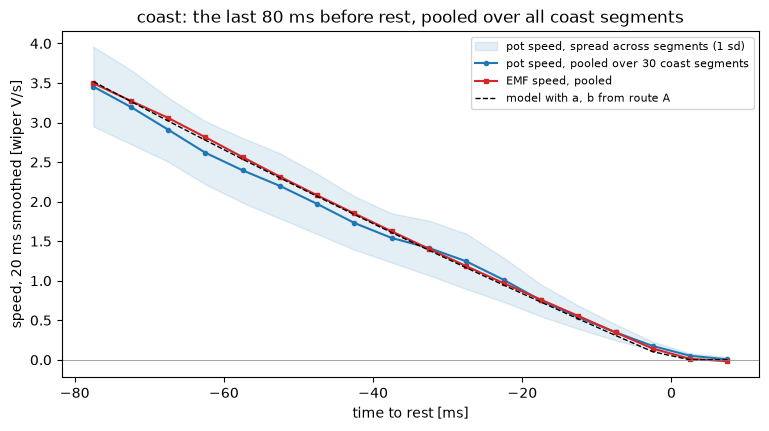

,v_pot,v_pot_sd,v_emf,v_emf_sd,dist_mV,v_pot_fwd,v_emf_fwd,v_pot_rev,v_emf_rev,v_model,dist_model_mV
bin center [ms to rest],,,,,,,,,,,
-77.5,3.454,0.504,3.497,0.196,127.356,3.220,3.582,3.657,3.424,3.519,131.497
-72.5,3.198,0.469,3.275,0.161,111.467,3.045,3.335,3.345,3.217,3.268,114.530
-67.5,2.912,0.406,3.060,0.176,96.626,2.869,3.123,2.954,2.996,3.021,98.807
-62.5,2.619,0.399,2.815,0.181,82.941,2.652,2.877,2.587,2.753,2.778,84.310
-57.5,2.396,0.409,2.563,0.172,70.533,2.466,2.621,2.326,2.506,2.538,71.024
-52.5,2.199,0.412,2.317,0.160,59.237,2.274,2.369,2.124,2.265,2.301,58.930
-47.5,1.971,0.380,2.080,0.147,48.317,2.025,2.126,1.918,2.034,2.067,48.013
-42.5,1.730,0.338,1.850,0.137,39.330,1.761,1.891,1.699,1.810,1.836,38.257
-37.5,1.541,0.311,1.624,0.129,31.360,1.564,1.660,1.517,1.588,1.609,29.645


In [16]:
A_COAST, B_COAST = route_a["a [wiper V/s2]"].mean(), route_a["b [1/s]"].mean()
REST_VPS = 0.1
HALF_WIN = SG_WIN // 2

traces = []
for name, f in coast_fits.items():
    for c in f["segs"]:
        p = c["p"]
        v = savgol_filter(p, SG_WIN, 2, deriv=1, delta=1 / TICK_HZ)
        e = np.where(coast_mask(c, spin_rails[name]), c["e"], 0.0)
        ve = savgol_filter(e, SG_WIN, 2) / f["slope"]
        t_rest = np.where(v[:-HALF_WIN] > REST_VPS)[0][-1] + 1
        p_rest = np.median(p[-1000:])
        tt = (np.arange(len(p)) - t_rest) / TICK_HZ * 1e3
        traces.append(pd.DataFrame({"dir": c["dir"], "t_ms": tt, "v_pot": v, "v_emf": ve,
                                    "dist": p_rest - p}))
tr = pd.concat(traces)
tr = tr[(tr["t_ms"] >= -80) & (tr["t_ms"] < 10)].copy()
tr["bin_ms"] = (tr["t_ms"] // 5) * 5
pooled = tr.groupby("bin_ms").agg(v_pot=("v_pot", "mean"), v_pot_sd=("v_pot", "std"),
                                  v_emf=("v_emf", "mean"), v_emf_sd=("v_emf", "std"),
                                  dist_mV=("dist", "mean"))
pooled["dist_mV"] *= 1e3
for d, label in [(1, "fwd"), (-1, "rev")]:
    g = tr[tr["dir"] == d].groupby("bin_ms")
    pooled[f"v_pot_{label}"] = g["v_pot"].mean()
    pooled[f"v_emf_{label}"] = g["v_emf"].mean()
tm = pooled.index.to_numpy() + 2.5
tp = np.maximum(-tm, 0) / 1e3     # time to rest, s
pooled["v_model"] = A_COAST / B_COAST * (np.exp(B_COAST * tp) - 1)
pooled["dist_model_mV"] = (A_COAST / B_COAST ** 2 * (np.exp(B_COAST * tp) - 1) - A_COAST / B_COAST * tp) * 1e3
pooled.index = tm
pooled.index.name = "bin center [ms to rest]"

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.fill_between(tm, pooled["v_pot"] - pooled["v_pot_sd"], pooled["v_pot"] + pooled["v_pot_sd"],
                color="tab:blue", alpha=0.12, label="pot speed, spread across segments (1 sd)")
ax.plot(tm, pooled["v_pot"], "-o", ms=3, color="tab:blue", label="pot speed, pooled over 30 coast segments")
ax.plot(tm, pooled["v_emf"], "-s", ms=3, color="tab:red", label="EMF speed, pooled")
ax.plot(tm, pooled["v_model"], "k--", lw=1, label="model with a, b from route A")
ax.axhline(0, color="grey", lw=0.5)
ax.set_xlabel("time to rest [ms]")
ax.set_ylabel("speed, 20 ms smoothed [wiper V/s]")
ax.set_title("coast: the last 80 ms before rest, pooled over all coast segments")
ax.legend(fontsize=8)
plt.show()

pooled.round(3)

In [17]:
def decel(series, lo, hi):
    m = (series.index >= lo) & (series.index <= hi)
    return -np.polyfit(series.index[m] / 1e3, series[m], 1)[0]

def parabola_a(series, lo):
    m = (series.index >= lo) & (series.index < 0)
    t2 = (series.index[m] / 1e3) ** 2
    return 2 * np.polyfit(t2, series[m] / 1e3, 1)[0]

rows = []
for lo, hi in [(-45, -15), (-25, -5)]:
    rows.append({"quantity": f"deceleration, {-lo} to {-hi} ms before rest [wiper V/s2]",
                 "pot, pooled": decel(pooled["v_pot"], lo, hi),
                 "pot, forward": decel(pooled["v_pot_fwd"], lo, hi),
                 "pot, reverse": decel(pooled["v_pot_rev"], lo, hi),
                 "EMF, pooled": decel(pooled["v_emf"], lo, hi),
                 "EMF, forward": decel(pooled["v_emf_fwd"], lo, hi),
                 "EMF, reverse": decel(pooled["v_emf_rev"], lo, hi),
                 "model": decel(pooled["v_model"], lo, hi)})
rows.append({"quantity": "parabola a over the last 40 ms of distance to rest [wiper V/s2]",
             "pot, pooled": parabola_a(pooled["dist_mV"], -40),
             "model": parabola_a(pooled["dist_model_mV"], -40)})
rows.append({"quantity": "Coulomb term a from route A [wiper V/s2]", "model": A_COAST})
near_tab = pd.DataFrame(rows).set_index("quantity").round(1)
display(near_tab)

# where the pooled EMF trace departs from the model, bin by bin
(pooled["v_emf"] / pooled["v_model"]).loc[lambda s: s.index < 0].round(3).to_frame("EMF / model")

,"pot, pooled","pot, forward","pot, reverse","EMF, pooled","EMF, forward","EMF, reverse",model
quantity,,,,,,,
"deceleration, 45 to 15 ms before rest [wiper V/s2]",38.0,38.8,37.2,43.6,44.5,42.7,44.2
"deceleration, 25 to 5 ms before rest [wiper V/s2]",44.0,43.0,45.1,41.5,42.5,40.4,42.4
parabola a over the last 40 ms of distance to rest [wiper V/s2],44.3,NaN,NaN,NaN,NaN,NaN,42.1
Coulomb term a from route A [wiper V/s2],NaN,NaN,NaN,NaN,NaN,NaN,40.7


,EMF / model
bin center [ms to rest],
-77.5,0.994
-72.5,1.002
-67.5,1.013
-62.5,1.014
-57.5,1.010
-52.5,1.007
-47.5,1.007
-42.5,1.008
-37.5,1.009


Findings:

- By the EMF the pooled deceleration is 43.6 wiper V/s$^2$ over 45 to 15 ms
  before rest and 41.5 over 25 to 5 ms, against the model's 44.2 and 42.4,
  so the rate of slowing agrees with the route A model within 1.4% and 2.1%
  pooled, and within 5% in either direction on its own. There is no plateau
  before rest and no abrupt stop from a finite speed, so the mechanism
  glides to rest under the same Coulomb term the fit found at speed, and no
  separate near-rest term is needed.
- The pooled EMF speed sits within 2.5% of the model from 77 ms out to
  22 ms before rest, then rises above it: 4% at 17 ms, 7% at 12 ms, 12% at
  7 ms and 40% in the last bin. A constant offset of a millisecond or two
  in the alignment reproduces that shape, and the alignment is the pot's
  rest instant through a 20 ms smoothing filter. The retired battery run
  held within 3% at every bin and the USB run reached 21% at 17 ms, so this
  session sits between them and the reading is unchanged: alignment, not a
  friction term.
- By the pot the pooled deceleration is 38.0 over 45 to 15 ms and 44.0 over
  25 to 5 ms, straddling the model rather than tracking it, and the two
  directions differ by 1.6 and 2.1 wiper V/s$^2$ in the two windows, much
  less than the 10 the USB run found. The pooled distance to rest over the
  last 40 ms gives a Coulomb term of 44.3 against the model's 42.1, so the
  position itself agrees with the model within 5.2% and the scatter sits in
  the pot-derived speed.
- *Hypothesis (not tested here): the pot ripple does not fully average out
  in this pool, since every coast of a given entry duty comes to rest near
  the same position and the ripple phases across recordings are therefore
  correlated. It is smaller here than on USB because the entry speeds are
  higher and the coasts longer, so a segment covers more ripple periods.*

### 8.2 Position dependence

One limit needs stating first, and on this dataset it is tighter than
before. Every step of a given duty starts from the same repositioned end,
and the travel-sized windows mean **every step of every duty also ends at
about the same place**. So position, duty, speed and time into the sweep
are confounded by design, and the position axis has collapsed to two bins
per direction. The figure plots the residual of every matched-range route B
step from its direction's line (section 6.1) against the step's position,
and the table bins it by position and by duty. The bins are shown for what
they are.

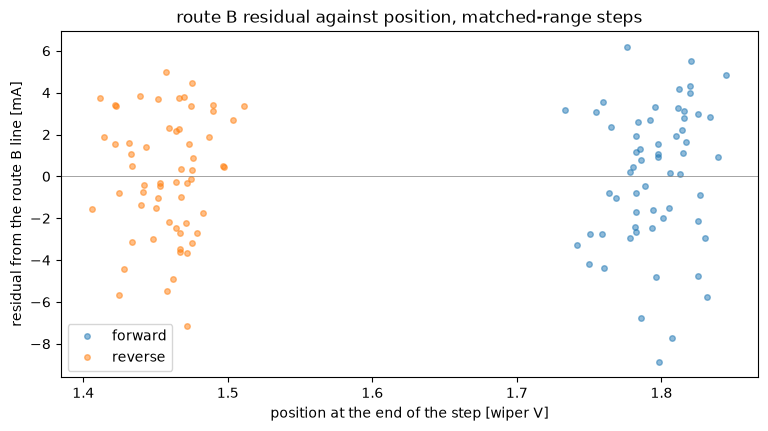

residual_mA  sd_mA  steps  duty_pct  \
direction position bin [wiper V]                                        
forward   1.7                           -0.52   3.20     35     26.43   
          1.8                            0.73   3.45     25     29.00   
reverse   1.4                           -0.10   2.88     58     27.93   
          1.5                            3.03   0.45      2     15.00   

                                  speed_Vps  
direction position bin [wiper V]             
forward   1.7                          5.26  
          1.8                          5.89  
reverse   1.4                          5.68  
          1.5                          2.55

In [18]:
rows = []
for d, label in [(1, "forward"), (-1, "reverse")]:
    f = route_b.loc[("extrapolated steady state", f"matched, <= {V_MATCH}", label)]
    g = grid_tab[(grid_tab["dir"] == d) & (grid_tab["v_ss_Vps"] <= V_MATCH)].copy()
    g["residual_mA"] = (g["i_ss_A"] - f["i_c [A]"] - f["i_v [A per wiper V/s]"] * g["v_ss_Vps"]) * 1e3
    g["direction"] = label
    rows.append(g)
res = pd.concat(rows)
res["position bin [wiper V]"] = (res["pos_V"] // 0.1) * 0.1

fig, ax = plt.subplots(figsize=(9, 4.5))
for label, color in [("forward", "tab:blue"), ("reverse", "tab:orange")]:
    g = res[res["direction"] == label]
    ax.plot(g["pos_V"], g["residual_mA"], "o", ms=4, alpha=0.5, color=color, label=label)
ax.axhline(0, color="grey", lw=0.5)
ax.set_xlabel("position at the end of the step [wiper V]")
ax.set_ylabel("residual from the route B line [mA]")
ax.set_title("route B residual against position, matched-range steps")
ax.legend()
plt.show()

by_pos = (res.groupby(["direction", "position bin [wiper V]"])
          .agg(residual_mA=("residual_mA", "mean"), sd_mA=("residual_mA", "std"),
               steps=("residual_mA", "size"), duty_pct=("mag_pct", "mean"), speed_Vps=("v_ss_Vps", "mean")))
by_pos.round(2)

In [19]:
# The same residuals binned by duty, which is the other axis of the confound.
(res.groupby(["direction", "mag_pct"])
    .agg(residual_mA=("residual_mA", "mean"), sd_mA=("residual_mA", "std"),
         steps=("residual_mA", "size"), speed_Vps=("v_ss_Vps", "mean"))
    .round(2))

residual_mA  sd_mA  steps  speed_Vps
direction mag_pct                                      
forward   15             -3.17   1.99     10       2.51
          20              1.10   2.52     10       3.70
          25              2.59   2.58     10       4.91
          30              1.67   2.98     10       6.13
          35              0.22   2.81     10       7.35
          40             -2.40   3.14     10       8.53
reverse   15              2.38   1.92     10       2.55
          20             -0.47   2.32     10       3.76
          25             -2.37   2.58     10       4.97
          30             -1.80   2.53     10       6.19
          35              0.71   2.47     10       7.39
          40              1.55   2.62     10       8.59

Findings:

- The matched-range steps end between 1.7 and 1.9 wiper V forward and 1.4
  and 1.6 reverse, so there are two position bins per direction and one of
  the reverse bins holds two steps. Everything but that thin bin sits
  within 0.8 mA of zero, against a steady current of 58 to 95 mA in the
  same range.
- Binned by duty the residuals lie within 3.2 mA of zero at every grid
  point from 15% to 40%, with a scatter of 2 to 3 mA within each bin. The
  15% point is the worst in both directions, -3.2 mA forward and +2.4 mA
  reverse, which is the slowest and noisiest step and the same place the
  USB run found its worst bin.
- Within the matched range friction shows no position dependence that this
  design can resolve. The design is now *less* able to resolve it than the
  80 ms grid was, because travel-sized windows put every step's endpoint in
  the same place on purpose. A test that separates position from speed
  needs steps of one duty started from several positions, which none of the
  three series provides.

## 9. Limitations

- **The board is a hacked rig.** The bus telemetry stream couples into the
  current amplifier output on this board (section 1). It is flat at rest on
  this firmware build, but a few counts is a few milliamps, and route B's
  line lives between 58 and 134 mA, so a few percent of $i_c$ is within
  reach of it. This is a limitation of this board, not something I code
  around.
- **One unit, one supply.** All numbers describe this one servo on one
  2-cell battery. The gear train has prior wear.
- **Voltages are nominal-referenced.** All voltages scale with the true VDD
  of this unit, which was not measured. The terminal rest readings are
  measured per recording and remove themselves from the EMF.
- **The onset band is one to two rungs wide, so the ladder now limits it.**
  The band is 5% to 6% forward and 5% to 7% reverse (section 5.1), and a 1%
  rung is 0.078 V of breakaway voltage at this rail. The capture-to-capture spread the USB run
  found may still be there and simply not resolved.
- **The breakaway current is model-derived** from notebook 03's resistance,
  which is itself in dispute between 4.5 [4.3, 4.8] and 4.22 [4.01, 4.43]
  (section 2). The whole onset band sits below the current floor on this
  supply, so no ladder can measure it directly here.
- **Route A's EMF-to-speed slope is not $K_e$.** It is $K_e$ divided by
  what the pot reports during a coast, and notebook 03 shows the pot
  overreports just after the bridge opens, because the gear backlash lets
  the output run on while the motor slows. The ratio $a/b$ does not care;
  $a$ and $b$ individually do, and every wiper-unit friction constant below
  inherits it.
- **Route B is provisional.** The two routes disagree by 17% forward and
  39% reverse in the ratio of Coulomb to viscous friction (section 7), the
  sign of the disagreement flips with the fit range, and route B alone
  carries a 31% direction asymmetry that route A does not see.
- **Route A's split is still range-limited.** The coast entries reach 8.5
  wiper V/s and the fitted crossover lies at 14.8, so $b$ rests on the
  curvature within the range. This is better than USB (4.6 against 7.08)
  and still not a direct measurement of $b$.
- **The pot ripple** limits every per-segment or per-step speed estimate at
  low speed, and it does not fully average out of a pool whose segments rest
  at correlated positions (section 8.1). The EMF and the extrapolated
  estimates avoid it, the per-step pot estimates do not.
- **Position, speed and duty are fully confounded** in the grid (section
  8.2), and the travel-sized windows make it worse than the flat-window
  grid did.

## 10. What the next notebooks use from here

- The breakaway band of 0.39 to 0.54 V (section 5.2), 0.39 to 0.47 V
  forward and 0.39 to 0.54 V reverse, as the dead zone any open-loop
  voltage command has to cross, and the model-derived breakaway current of
  0.086 to 0.121 A with notebook 03's resistance. The lower edge, 0.39 V,
  which agrees with the retired battery run to 5%, is the robust half.
- The friction constants of route A, Coulomb 40.7 wiper V/s$^2$ and viscous
  2.76 1/s with a crossover at 14.8 wiper V/s (section 6.2), as the
  friction terms of the plant model, carrying the caveat that the wiper
  unit is a pot reading during a coast (section 9). The approach to rest
  follows them with no separate near-rest term (section 8.1).
- The route B lines of section 6.1, $i_c$ of 0.0555 and 0.0460 A and $i_v$
  of 0.0045 and 0.0051 A per wiper V/s forward and reverse in the matched
  range, as the measured steady current at every grid point, for notebook
  03 to compare with its prediction from speed, resistance and back-EMF
  constant.
- The drive time constant of 18 to 21 ms (section 6.1), flat across the
  grid, which the inertia notebook combines with the coast damping of
  2.76 1/s and the brake damping of notebook 01 to separate inertia from
  the electrical damping.
- The fact that **travel-sized drive windows settle** where 80 ms ones did
  not (section 6.1): the reference-window and extrapolated route B lines
  now agree to within 8% in the matched range, against a factor of two on
  the 80 ms grid. Any later series that wants a steady state should size
  its windows this way.
- The settled ramp current of 64 to 76 mA at 14 to 18% duty, above
  breakaway, which is a friction current at a known duty.
- The EMF as the near-rest speed signal of choice, since the pooled pot
  speed carries a correlated ripple residue that the EMF does not (section
  8.1).
- The fact that the grid confounds position with speed, and now with
  endpoint too, so a position-dependence test needs a dedicated series.

## 11. Open discrepancies

Each item is a live disagreement, with the candidates that could produce it
and the one measurement that would tell them apart.

**1. Route A and route B give crossover speeds 17% and 39% apart, and the
sign flips with the fit range.**

Route A gives 14.77 wiper V/s. Route B gives 12.21 forward and 8.97 reverse
in the matched range, 18.4 and 12.5 in the extended range, 19.2 and 16.5
over the full grid.

- *Candidate A:* the drive current at speed carries a term besides
  friction. At speed the drive current is the small difference between the
  applied voltage and the back-EMF, so any speed-dependent drop that is
  absent at stall appears as a term proportional to speed and inflates
  $i_v$.
- *Candidate B:* the current-speed relation is curved and neither route is
  fitting a line to a line. Route B crossing route A around 10 wiper V/s is
  what curvature looks like.
- *Candidate C:* route A's $b$ is not measured but inferred from curvature
  inside a range whose top is well below the crossover.
- *Discriminating experiment:* the one this series can now run without new
  hardware. Notebook 03 has $K_e$ = 7.584 mV per motor rev/s and $R$ = 4.22
  Ohm from these same captures, so predict the steady current at every grid
  point as $(D\,V_{rail} - K_e\,\omega)/R$ and subtract it from the
  measured current. What is left is either flat (candidate A is wrong and
  route B is friction) or rises with speed (candidate A). This test was not
  worth running before because the earlier $K_e$ was a pot-referenced
  bracket 16% wide; it now rests on a route with 0.94% spread.

**2. Route B carries a 31% direction asymmetry and route A carries 5%.**

- *Candidate A:* something electrical and direction-dependent in the drive
  path, a switch, a diode or the shunt's position relative to the two
  half-bridges, which route A never exercises because it coasts.
- *Candidate B:* the two directions traverse different stretches of the
  pot, and route B reads speed from the pot while route A reads it from the
  EMF. A pot linearity error would show as a direction asymmetry in route B
  only. Notebook 06 measures pot linearity.
- *Candidate C:* real mechanical asymmetry that only shows under load, one
  flank of every mesh being worn differently.
- *Discriminating experiment:* run the grid with the motor leads swapped
  and the commanded direction inverted, so "forward" uses the other
  half-bridge over the same stretch of travel. If the asymmetry follows the
  bridge it is candidate A; if it stays with the travel it is candidate B
  or C, and notebook 06's linearity separates those two.

**3. Route A's constants moved 18 to 38% from the retired runs while its
ratio moved by a factor of two.**

- *Candidate A:* the wider speed range. Entries reach 8.5 wiper V/s against
  4.6 on USB, and a wider span is exactly what re-splits a constant term
  from a proportional one. This predicts the move is a correction, not a
  drift.
- *Candidate B:* the mechanism changed between sessions, through wear or
  through the gear service.
- *Candidate C:* the EMF-to-speed slope changed, since it is a pot-referenced
  quantity and the backlash bias of notebook 03 affects it.
- *Discriminating experiment:* refit route A on this dataset restricted to
  the coast segments whose entries fall inside the USB run's range, 4.6
  wiper V/s and below. If the constants move back toward the USB values it
  is candidate A and the wider range is the improvement it looks like. If
  they do not, candidates B and C are live and only a repeat capture
  separates them.

**4. Breakaway voltage: 0.39 to 0.54 V here, 0.37 to 0.51 V on the retired
battery run, 0.41 to 0.68 V as the USB run reported it and 0.32 to 0.55 V
when this notebook's criterion is applied to the USB captures.**

- *Candidate A:* the USB upper edge is supply sag. The rung that moves the
  mechanism *every* time is inflated on a rail that drops as motion starts.
- *Candidate B:* session-to-session variation in the mechanism, which the
  USB run saw directly as a capture-to-capture spread.
- *Candidate C:* the criterion. The published USB band and this notebook's
  recomputation of the same captures differ by 0.13 V at the top purely in
  how "every capture moves" is defined, which is a warning that the upper
  edge is a definition as much as a measurement.
- *Discriminating experiment:* a ramp on 2S with a finer ladder, 0.25% per
  rung through 4 to 8%. If the onset band stays two ordinary rungs wide the
  mechanism is repeatable and candidate A carries the USB width. If it
  spreads out to the same 3-to-1 width, candidate B is real and was merely
  unresolved here.

**5. The winding resistance input is 4.5 [4.3, 4.8] in the registry and
4.22 [4.01, 4.43] from notebook 03 on this dataset.**

Everything model-derived in section 5.3 carries the union of the two.

- *Candidate A:* the residual entry EMF in notebook 03's anchor window,
  which is three times larger on 2S and is bracketed rather than corrected.
- *Candidate B:* the retired run's ADC interpolation, which touched the
  current channel through the inrush band.
- *Discriminating experiment:* a locked-rotor step. Clamp the output horn,
  apply a short full-duty pulse, read $v/i$ with no back-EMF term at all.
  Notebook 03 lists the same experiment for the same reason, and one
  capture settles it for both notebooks.

**6. The near-rest EMF trace departs from the model inside 17 ms, reaching
40% in the last bin.**

- *Candidate A:* alignment. The rest instant comes from the pot through a
  20 ms smoothing filter, and a millisecond or two of offset reproduces the
  whole shape.
- *Candidate B:* a real near-rest friction term that the Coulomb-plus-viscous
  model does not carry, which is the question section 8.1 was asked to
  answer.
- *Discriminating experiment:* align on the **EMF's** own zero crossing
  instead of the pot's rest instant and repeat the comparison. The EMF is
  not smoothed by a 20 ms window before the alignment is taken, so if the
  departure disappears it was candidate A. If it survives an EMF-anchored
  alignment, candidate B is real and the model needs a third term.